# Unsupervised Detection of Phishing Campaigns

### Github Repository
- https://github.com/itsmostafa/unsupervised-detection-of-phishing-campaigns

**Dataset**: PhiUSIIL Phishing URL Dataset (30,000 instances, 54 features)

**Objective**: Simulate zero-day phishing detection in a Security Operations Center (SOC) environment using unsupervised machine learning techniques.

**Approach**: We will implement and compare multiple unsupervised learning methods:
- **Anomaly Detection**: Isolation Forest, Local Outlier Factor (LOF)
- **Clustering**: DBSCAN, K-Means

**Key Constraint**: All models must learn from features only. The target label will be separated immediately and used only for final validation.

## 1. Data Ingestion & Initial Inspection

In [70]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [71]:
def load_and_inspect_data(filepath):
    """
    Load the phishing dataset and perform initial inspection.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file containing the PhiUSIIL dataset
    
    Returns:
    --------
    df : pd.DataFrame
        Loaded dataset
    """
    # Load dataset
    df = pd.read_csv(filepath, encoding='utf-8')
    
    print("=" * 80)
    print("DATASET OVERVIEW")
    print("=" * 80)
    print(f"\nDataset shape: {df.shape}")
    print(f"Number of features: {df.shape[1] - 1}")  # Excluding label
    print(f"Number of instances: {df.shape[0]}")
    
    print("\n" + "=" * 80)
    print("DATA TYPES")
    print("=" * 80)
    print(df.dtypes)
    
    print("\n" + "=" * 80)
    print("MEMORY USAGE")
    print("=" * 80)
    print(df.memory_usage(deep=True))
    print(f"\nTotal memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print("\n" + "=" * 80)
    print("FIRST 5 ROWS")
    print("=" * 80)
    print(df.head())
    
    return df

In [72]:
# Load the dataset
df = load_and_inspect_data('data/phiusill-phishing-url.csv')

DATASET OVERVIEW

Dataset shape: (30000, 56)
Number of features: 55
Number of instances: 30000

DATA TYPES
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCha

In [73]:
def check_data_quality(df):
    """
    Check for missing values, duplicates, and basic data quality issues.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataset to analyze
    """
    print("=" * 80)
    print("DATA QUALITY ASSESSMENT")
    print("=" * 80)
    
    # Check for missing values
    missing_counts = df.isnull().sum()
    missing_percent = (missing_counts / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_counts,
        'Percentage': missing_percent
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    
    if len(missing_df) > 0:
        print("\nMissing Values:")
        print(missing_df)
    else:
        print("\n- No missing values found")
    
    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicates}")
    if duplicates == 0:
        print("- No duplicate rows found")
    
    # Check label distribution
    print("\n" + "=" * 80)
    print("LABEL DISTRIBUTION")
    print("=" * 80)
    print(df['label'].value_counts())
    print(f"\nClass balance:")
    print(df['label'].value_counts(normalize=True) * 100)

# Check data quality
check_data_quality(df)

DATA QUALITY ASSESSMENT

- No missing values found

Duplicate rows: 0
- No duplicate rows found

LABEL DISTRIBUTION
label
1    17596
0    12404
Name: count, dtype: int64

Class balance:
label
1    58.653333
0    41.346667
Name: proportion, dtype: float64


In [74]:
# Separate features and labels
print("=" * 80)
print("SEPARATING FEATURES AND TARGET")
print("=" * 80)

# Store labels for later validation
y_true = df['label'].values

# Remove non-feature columns (FILENAME, URL, Domain, Title are identifiers/text)
# Remove TLD (categorical string column that needs encoding)
# Remove label column to ensure unsupervised learning
columns_to_drop = ['FILENAME', 'URL', 'Domain', 'Title', 'TLD', 'label']
X = df.drop(columns=columns_to_drop)

print(f"\nOriginal dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_true.shape}")
print(f"\nRemoved columns: {columns_to_drop}")
print(f"\nRemaining feature columns ({len(X.columns)}):")
print(X.columns.tolist())

SEPARATING FEATURES AND TARGET

Original dataset shape: (30000, 56)
Features shape: (30000, 50)
Labels shape: (30000,)

Removed columns: ['FILENAME', 'URL', 'Domain', 'Title', 'TLD', 'label']

Remaining feature columns (50):
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightI

## 2. Exploratory Data Analysis (EDA)

In this section, we will:
1. Describe each feature and its characteristics
2. Visualize distributions using box plots and histograms
3. Analyze correlations between features
4. Assess the need for data transformations
5. Detect and handle outliers

In [75]:
def describe_features(X):
    """
    Generate comprehensive statistical summary of all features.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    """
    print("=" * 80)
    print("FEATURE STATISTICS")
    print("=" * 80)
    
    # Basic statistics
    stats = X.describe().T
    stats['skewness'] = X.skew()
    stats['kurtosis'] = X.kurtosis()
    
    print(stats)
    
    return stats

# Generate feature statistics
feature_stats = describe_features(X)

FEATURE STATISTICS
                              count          mean            std        min  \
URLLength                   30000.0     33.228067      44.016682  13.000000   
DomainLength                30000.0     21.123267       8.518198   4.000000   
IsDomainIP                  30000.0      0.002200       0.046853   0.000000   
URLSimilarityIndex          30000.0     80.137970      27.681432   0.155574   
CharContinuationRate        30000.0      0.854670       0.211049   0.000000   
TLDLegitimateProb           30000.0      0.263328       0.251415   0.000000   
URLCharProb                 30000.0      0.056113       0.010483   0.001223   
TLDLength                   30000.0      2.767033       0.591922   2.000000   
NoOfSubDomain               30000.0      1.165467       0.577724   0.000000   
HasObfuscation              30000.0      0.002033       0.045047   0.000000   
NoOfObfuscatedChar          30000.0      0.014400       0.399997   0.000000   
ObfuscationRatio            30000

BOX PLOTS - Identifying Outliers and Quartile Distributions


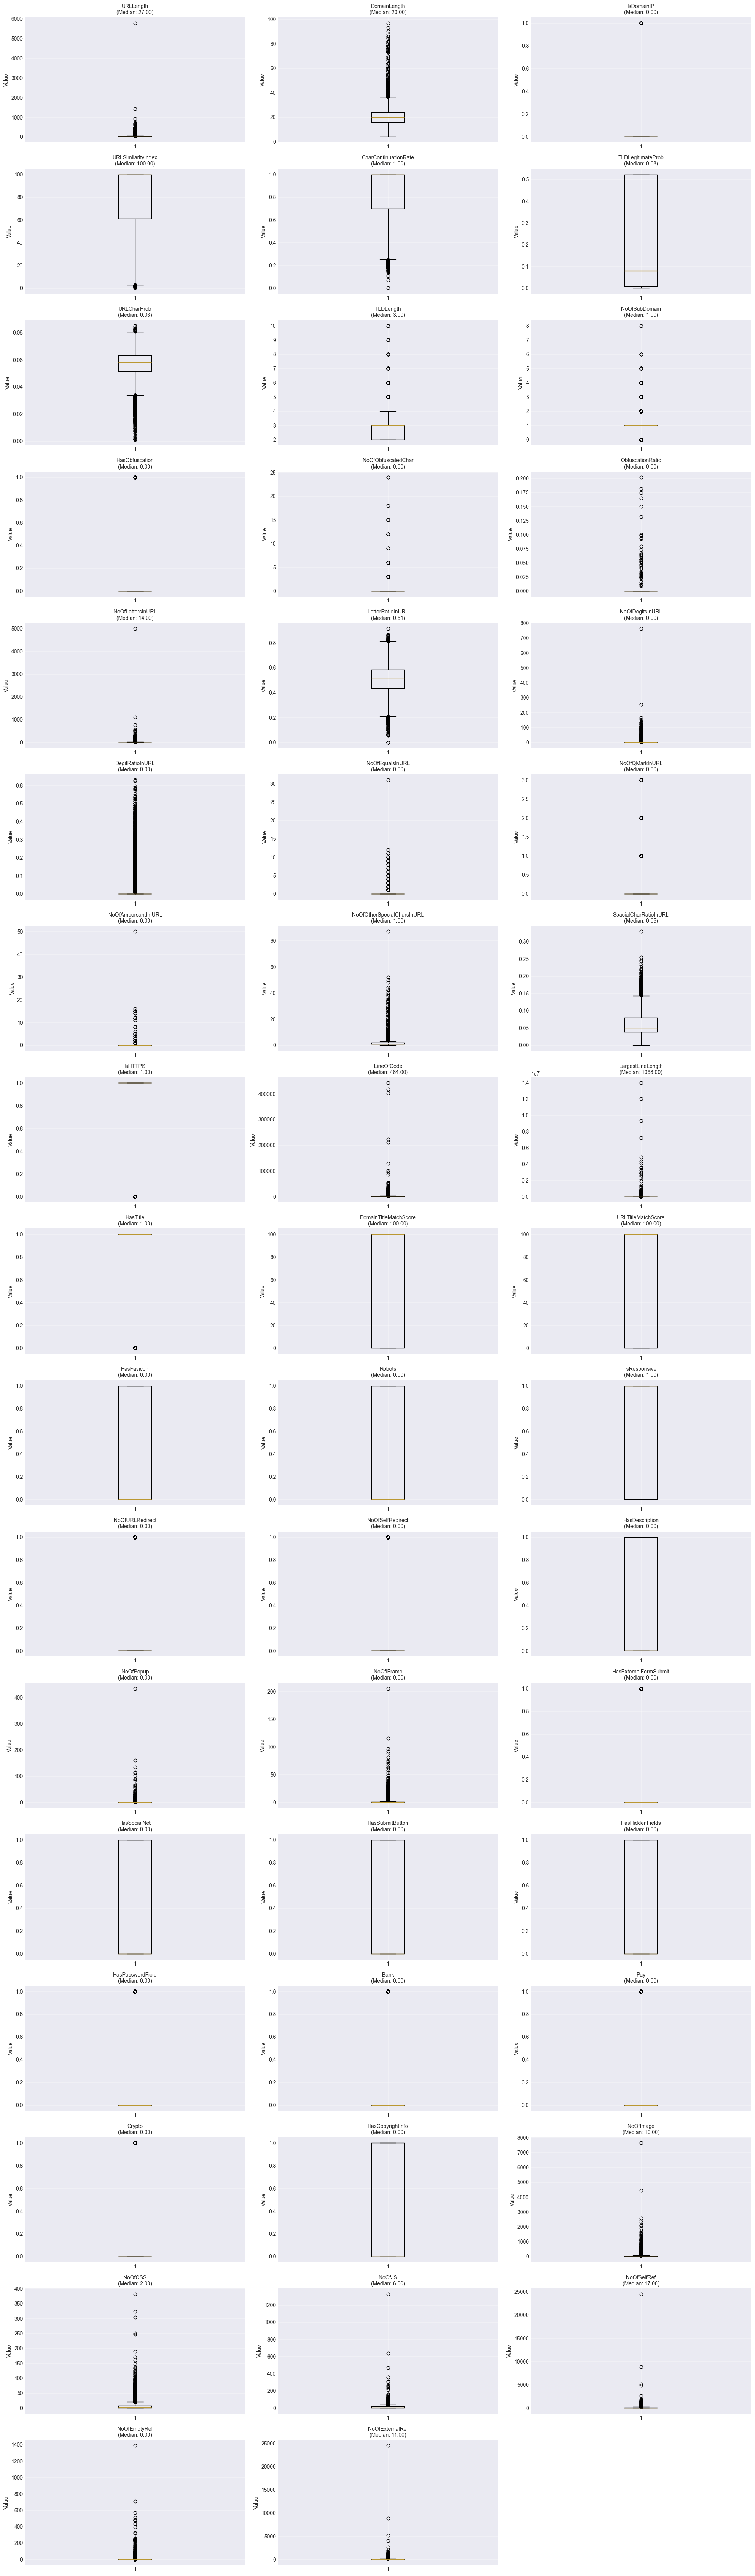


HISTOGRAMS - Distribution and Skewness Analysis


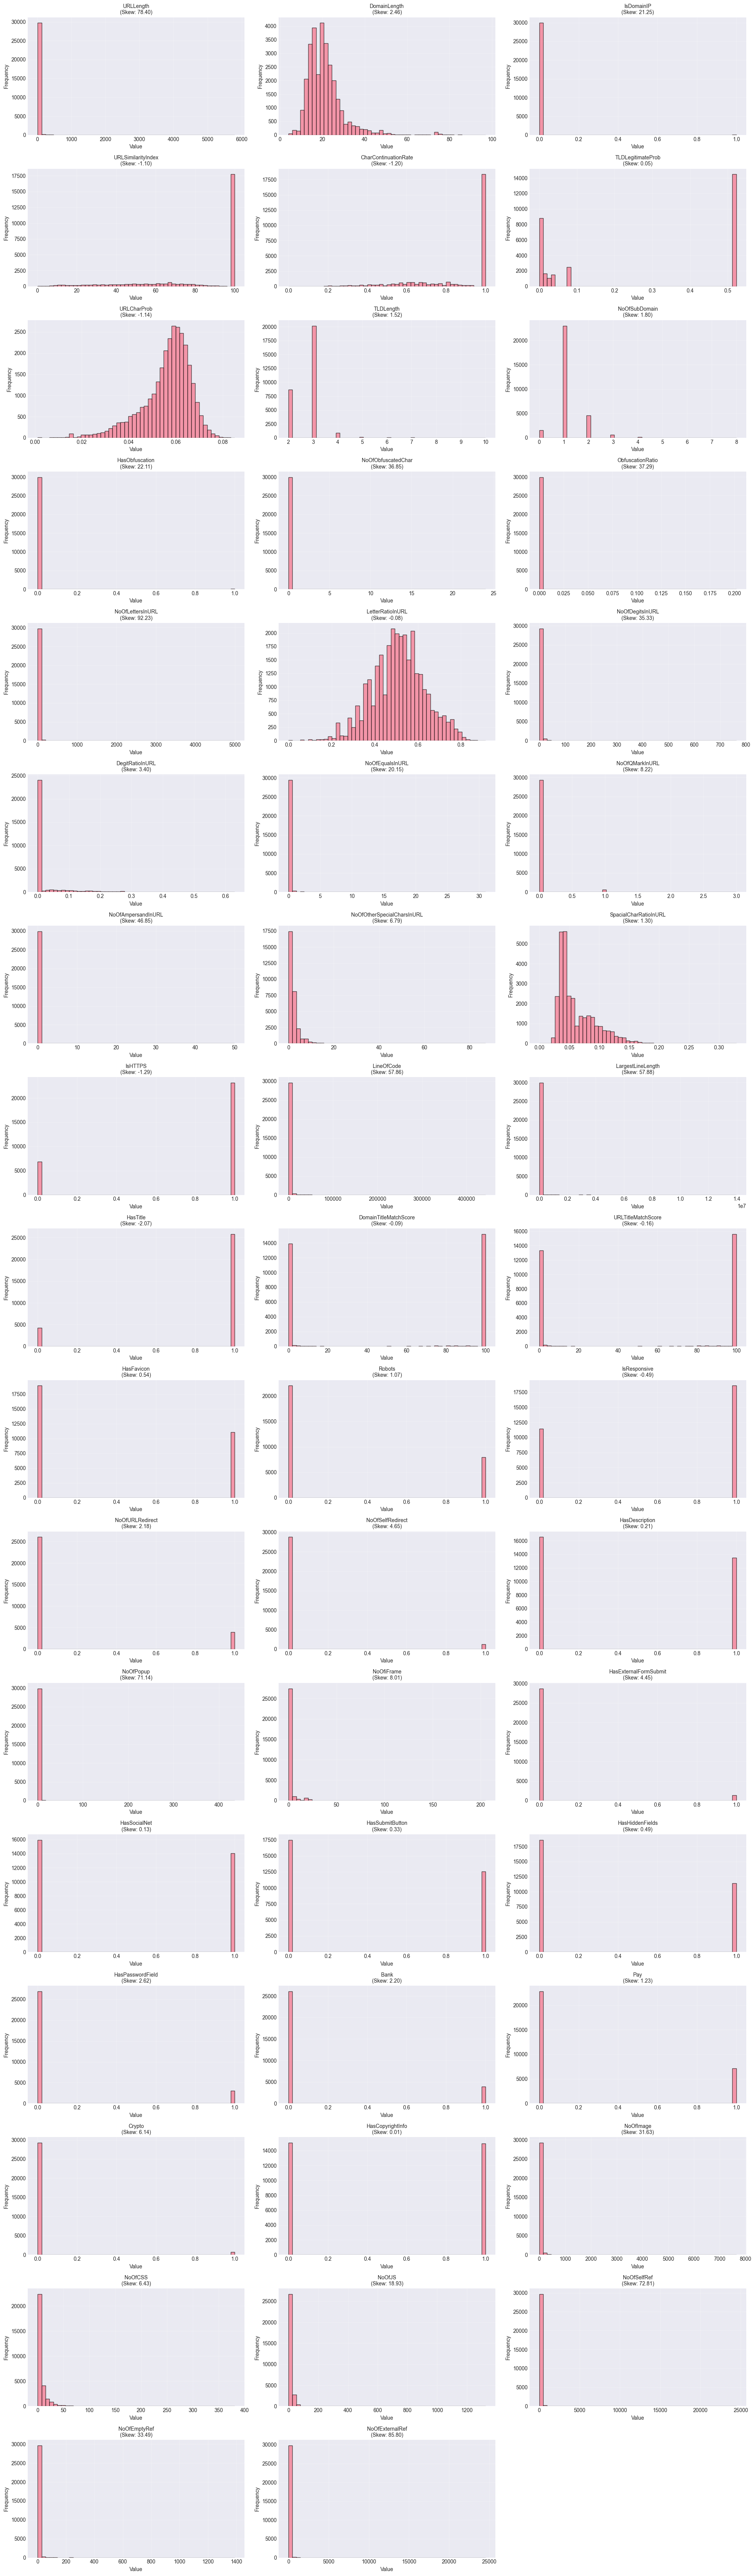

In [76]:
def visualize_feature_distributions(X, features_per_row=3):
    """
    Create box plots and histograms for all numerical features.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    features_per_row : int
        Number of features to display per row
    """
    numerical_features = X.select_dtypes(include=[np.number]).columns
    n_features = len(numerical_features)
    n_rows = (n_features + features_per_row - 1) // features_per_row
    
    # Box plots
    print("=" * 80)
    print("BOX PLOTS - Identifying Outliers and Quartile Distributions")
    print("=" * 80)
    
    fig, axes = plt.subplots(n_rows, features_per_row, figsize=(20, n_rows * 4))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(numerical_features):
        axes[idx].boxplot(X[feature].dropna(), vert=True)
        axes[idx].set_title(f'{feature}\n(Median: {X[feature].median():.2f})', fontsize=10)
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Histograms
    print("\n" + "=" * 80)
    print("HISTOGRAMS - Distribution and Skewness Analysis")
    print("=" * 80)
    
    fig, axes = plt.subplots(n_rows, features_per_row, figsize=(20, n_rows * 4))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(numerical_features):
        axes[idx].hist(X[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{feature}\n(Skew: {X[feature].skew():.2f})', fontsize=10)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize distributions
visualize_feature_distributions(X)

SCATTER PLOTS - Key Feature Relationships


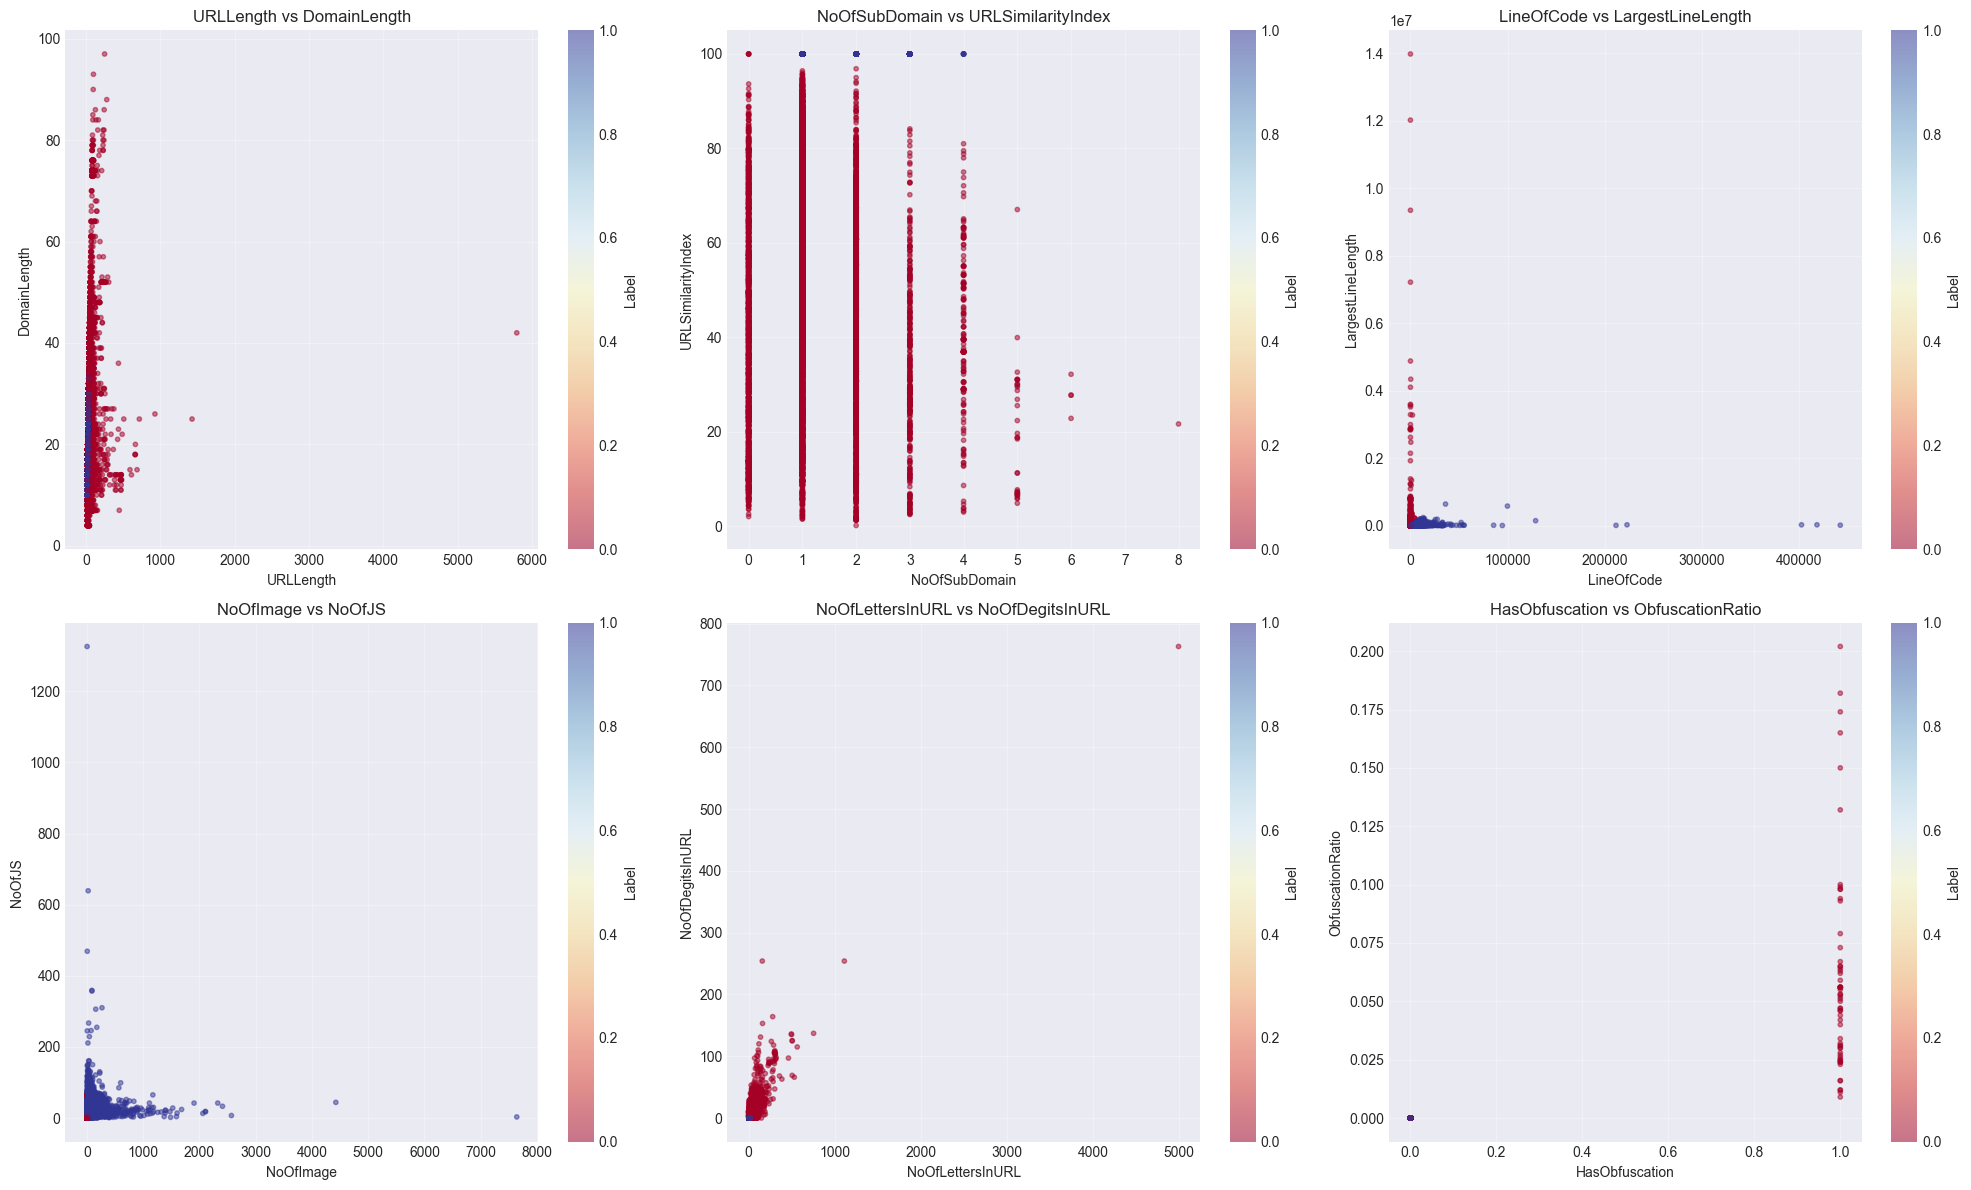

In [77]:
def analyze_key_feature_relationships(X, y_true):
    """
    Create scatter plots to examine relationships between key features.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    y_true : np.array
        Ground truth labels (for coloring only, not for training)
    """
    print("=" * 80)
    print("SCATTER PLOTS - Key Feature Relationships")
    print("=" * 80)
    
    # Select key features to visualize
    key_pairs = [
        ('URLLength', 'DomainLength'),
        ('NoOfSubDomain', 'URLSimilarityIndex'),
        ('LineOfCode', 'LargestLineLength'),
        ('NoOfImage', 'NoOfJS'),
        ('NoOfLettersInURL', 'NoOfDegitsInURL'),
        ('HasObfuscation', 'ObfuscationRatio')
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, (feat1, feat2) in enumerate(key_pairs):
        scatter = axes[idx].scatter(X[feat1], X[feat2], c=y_true, 
                                   cmap='RdYlBu', alpha=0.5, s=10)
        axes[idx].set_xlabel(feat1, fontsize=10)
        axes[idx].set_ylabel(feat2, fontsize=10)
        axes[idx].set_title(f'{feat1} vs {feat2}', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[idx], label='Label')
    
    plt.tight_layout()
    plt.show()

# Analyze key relationships
analyze_key_feature_relationships(X, y_true)

### 2.1 Correlation Analysis

CORRELATION ANALYSIS


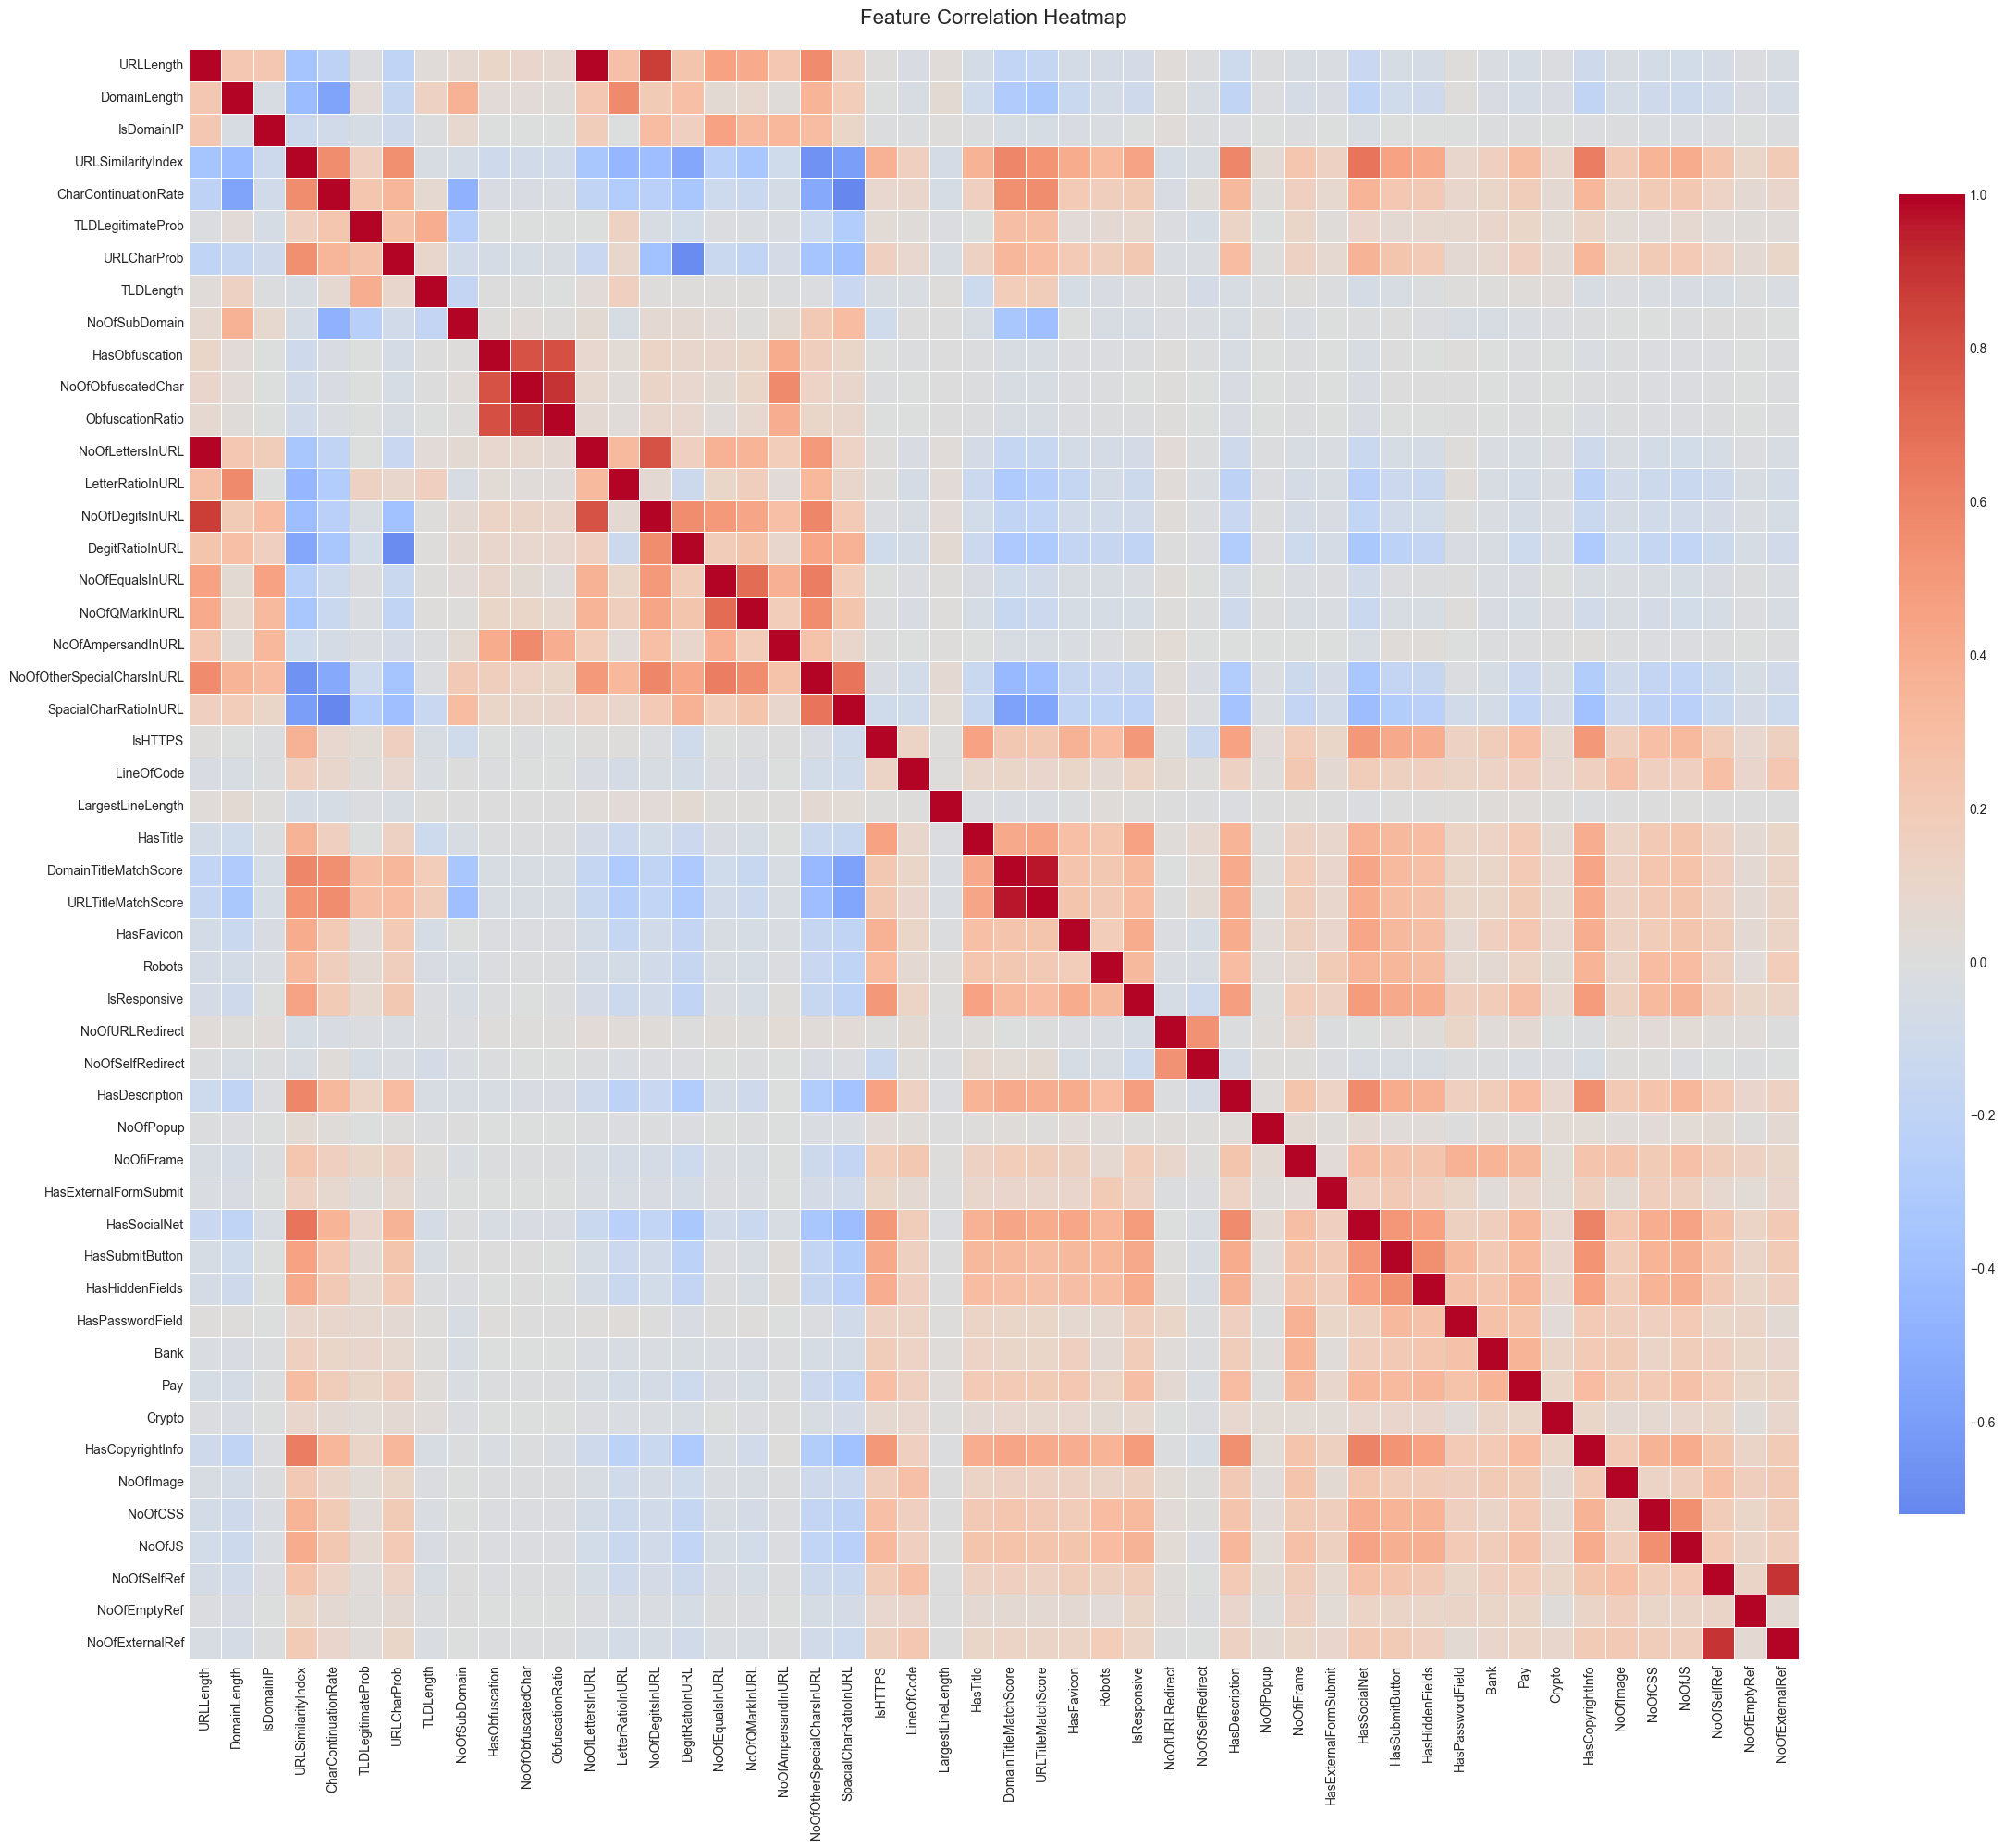


Highly Correlated Feature Pairs (|correlation| > 0.8):
            Feature 1          Feature 2  Correlation
            URLLength   NoOfLettersInURL     0.989508
DomainTitleMatchScore URLTitleMatchScore     0.964923
   NoOfObfuscatedChar   ObfuscationRatio     0.904296
          NoOfSelfRef    NoOfExternalRef     0.895769
            URLLength    NoOfDegitsInURL     0.869798
       HasObfuscation   ObfuscationRatio     0.810663

⚠ Found 6 highly correlated feature pairs
These features may exhibit multicollinearity.


In [78]:
def analyze_correlations(X, threshold=0.8):
    """
    Generate correlation heatmap and identify highly correlated features.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    threshold : float
        Correlation threshold for identifying multicollinearity
    
    Returns:
    --------
    corr_matrix : pd.DataFrame
        Correlation matrix
    """
    print("=" * 80)
    print("CORRELATION ANALYSIS")
    print("=" * 80)
    
    # Calculate correlation matrix
    corr_matrix = X.corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(24, 20))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated pairs
    print(f"\nHighly Correlated Feature Pairs (|correlation| > {threshold}):")
    print("=" * 80)
    
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    high_corr_df = pd.DataFrame(high_corr_pairs, 
                                columns=['Feature 1', 'Feature 2', 'Correlation'])
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False, key=abs)
    
    if len(high_corr_df) > 0:
        print(high_corr_df.to_string(index=False))
        print(f"\n⚠ Found {len(high_corr_df)} highly correlated feature pairs")
        print("These features may exhibit multicollinearity.")
    else:
        print(f"- No feature pairs with |correlation| > {threshold}")
    
    return corr_matrix

# Analyze correlations
corr_matrix = analyze_correlations(X, threshold=0.8)

### 2.2 Data Transformation Assessment

In [79]:
def assess_transformations(X):
    """
    Assess whether features need transformation based on their distributions.
    
    Criteria:
    - High skewness (|skew| > 1): Consider log transformation
    - Different scales: Normalization/standardization required
    - High kurtosis: Indicates presence of outliers
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    """
    print("=" * 80)
    print("DATA TRANSFORMATION ASSESSMENT")
    print("=" * 80)
    
    # Analyze skewness
    skewness = X.skew().sort_values(ascending=False, key=abs)
    highly_skewed = skewness[abs(skewness) > 1]
    
    print("\n1. SKEWNESS ANALYSIS")
    print("-" * 80)
    print(f"Features with high skewness (|skew| > 1): {len(highly_skewed)}")
    if len(highly_skewed) > 0:
        print("\nTop 10 most skewed features:")
        print(highly_skewed.head(10))
        print("\n⚠ Recommendation: These features may benefit from log transformation")
    
    # Analyze scale differences
    print("\n2. SCALE ANALYSIS")
    print("-" * 80)
    ranges = X.max() - X.min()
    print(f"Minimum range: {ranges.min():.4f}")
    print(f"Maximum range: {ranges.max():.4f}")
    print(f"Range ratio: {ranges.max() / (ranges.min() + 1e-10):.2f}")
    print("\n- Recommendation: Use RobustScaler to handle different scales and outliers")
    
    # Analyze kurtosis
    print("\n3. KURTOSIS ANALYSIS (Outlier Indicator)")
    print("-" * 80)
    kurtosis = X.kurtosis().sort_values(ascending=False)
    high_kurtosis = kurtosis[kurtosis > 3]
    print(f"Features with high kurtosis (> 3): {len(high_kurtosis)}")
    if len(high_kurtosis) > 0:
        print("\nTop 10 features with highest kurtosis:")
        print(high_kurtosis.head(10))
        print("\n⚠ High kurtosis indicates heavy tails and potential outliers")
    
    print("\n" + "=" * 80)
    print("TRANSFORMATION STRATEGY")
    print("=" * 80)
    print("""
Based on the EDA findings:

1. SCALING: Apply RobustScaler
   - Rationale: Features have vastly different scales (range ratio > 1000)
   - Advantage: RobustScaler uses median and IQR, making it robust to outliers
   - Alternative: StandardScaler would be affected by outliers in our data

2. LOG TRANSFORMATION: Not applying directly
   - Rationale: RobustScaler will handle skewness adequately
   - Some features contain zeros, which would cause issues with log(0)
   - PCA after scaling will capture variance patterns effectively

3. DIMENSIONALITY REDUCTION: Apply PCA (95% variance)
   - Rationale: 51 numerical features may contain redundancy
   - Benefit: Reduces noise, speeds up computation, helps visualization
   - Threshold: Retain 95% of variance to preserve information
    """)

# Assess need for transformations
assess_transformations(X)

DATA TRANSFORMATION ASSESSMENT

1. SKEWNESS ANALYSIS
--------------------------------------------------------------------------------
Features with high skewness (|skew| > 1): 39

Top 10 most skewed features:
NoOfLettersInURL      92.227938
NoOfExternalRef       85.800125
URLLength             78.395552
NoOfSelfRef           72.811473
NoOfPopup             71.142670
LargestLineLength     57.876504
LineOfCode            57.862744
NoOfAmpersandInURL    46.848522
ObfuscationRatio      37.289094
NoOfObfuscatedChar    36.852594
dtype: float64

⚠ Recommendation: These features may benefit from log transformation

2. SCALE ANALYSIS
--------------------------------------------------------------------------------
Minimum range: 0.0839
Maximum range: 13975709.0000
Range ratio: 166630345.48

- Recommendation: Use RobustScaler to handle different scales and outliers

3. KURTOSIS ANALYSIS (Outlier Indicator)
--------------------------------------------------------------------------------
Features w

### 2.3 Outlier Detection and Data Cleaning

In [80]:
def detect_outliers(X, method='IQR'):
    """
    Detect outliers using IQR method.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    method : str
        Method for outlier detection ('IQR' or 'Z-score')
    
    Returns:
    --------
    outlier_mask : pd.DataFrame
        Boolean mask indicating outliers for each feature
    """
    print("=" * 80)
    print(f"OUTLIER DETECTION - {method} Method")
    print("=" * 80)
    
    outlier_mask = pd.DataFrame(False, index=X.index, columns=X.columns)
    
    if method == 'IQR':
        print("\nUsing IQR method: Outliers are values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR")
        for col in X.select_dtypes(include=[np.number]).columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outlier_mask[col] = (X[col] < lower_bound) | (X[col] > upper_bound)
    
    elif method == 'Z-score':
        print("\nUsing Z-score method: Outliers are values with |Z-score| > 3")
        for col in X.select_dtypes(include=[np.number]).columns:
            z_scores = np.abs((X[col] - X[col].mean()) / X[col].std())
            outlier_mask[col] = z_scores > 3
    
    # Summary statistics
    outlier_counts = outlier_mask.sum().sort_values(ascending=False)
    outlier_percent = (outlier_counts / len(X)) * 100
    
    outlier_summary = pd.DataFrame({
        'Outlier Count': outlier_counts,
        'Percentage': outlier_percent
    })
    
    print("\nTop 15 features with most outliers:")
    print(outlier_summary.head(15))
    
    # Rows with any outlier
    rows_with_outliers = outlier_mask.any(axis=1).sum()
    print(f"\nTotal rows with at least one outlier: {rows_with_outliers} ({rows_with_outliers/len(X)*100:.2f}%)")
    
    return outlier_mask

# Detect outliers
outlier_mask = detect_outliers(X, method='IQR')

OUTLIER DETECTION - IQR Method

Using IQR method: Outliers are values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR

Top 15 features with most outliers:
                            Outlier Count  Percentage
Pay                                  7160   23.866667
NoOfSubDomain                        6991   23.303333
IsHTTPS                              6872   22.906667
NoOfDegitsInURL                      5973   19.910000
DegitRatioInURL                      5973   19.910000
NoOfEmptyRef                         5163   17.210000
NoOfOtherSpecialCharsInURL           4473   14.910000
NoOfiFrame                           4419   14.730000
HasTitle                             4209   14.030000
NoOfURLRedirect                      3946   13.153333
Bank                                 3904   13.013333
HasPasswordField                     3073   10.243333
NoOfExternalRef                      2937    9.790000
URLLength                            2684    8.946667
NoOfLettersInURL                     2410    8.033

### Data Cleaning Strategy

Decision: Retain all data points including outliers

Rationale:
1. Domain Context: In phishing detection, "outliers" may represent actual phishing attempts
   - Extreme URL lengths, unusual character patterns, etc. are phishing indicators
   - Removing outliers could eliminate the very patterns we want to detect

2. Unsupervised Learning: Outliers are valuable for anomaly detection methods
   - Isolation Forest specifically targets outliers as anomalies
   - DBSCAN can identify outlier clusters as noise points

3. Data Quality: No missing values or duplicates detected
   - No imputation required
   - No duplicate removal needed

4. Robust Preprocessing: RobustScaler will handle outliers in the next step
   - Uses median and IQR instead of mean and std
   - Less sensitive to extreme values

Conclusion: Proceed with full dataset (30,000 instances, 51 features)

In [81]:
def clean_data_strategy(X, outlier_mask):
    """
    Define and execute data cleaning strategy.
    """
    
    # No changes to the data
    X_clean = X.copy()
    
    print(f"\nFinal dataset shape: {X_clean.shape}")
    print(f"No rows removed, all {len(X_clean)} instances retained")
    
    return X_clean

# Apply cleaning strategy
X_clean = clean_data_strategy(X, outlier_mask)


Final dataset shape: (30000, 50)
No rows removed, all 30000 instances retained


### 2.4 Dimensionality Visualization (t-SNE)

t-SNE DIMENSIONALITY REDUCTION

Sampling 5000 instances for t-SNE visualization...

Applying t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.000s...
[t-SNE] Computed neighbors for 5000 samples in 0.058s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 1.116681
[t-SNE] KL divergence after 250 iterations with early exaggeration: 76.134247
[t-SNE] KL divergence after 1000 iterations: 1.356290


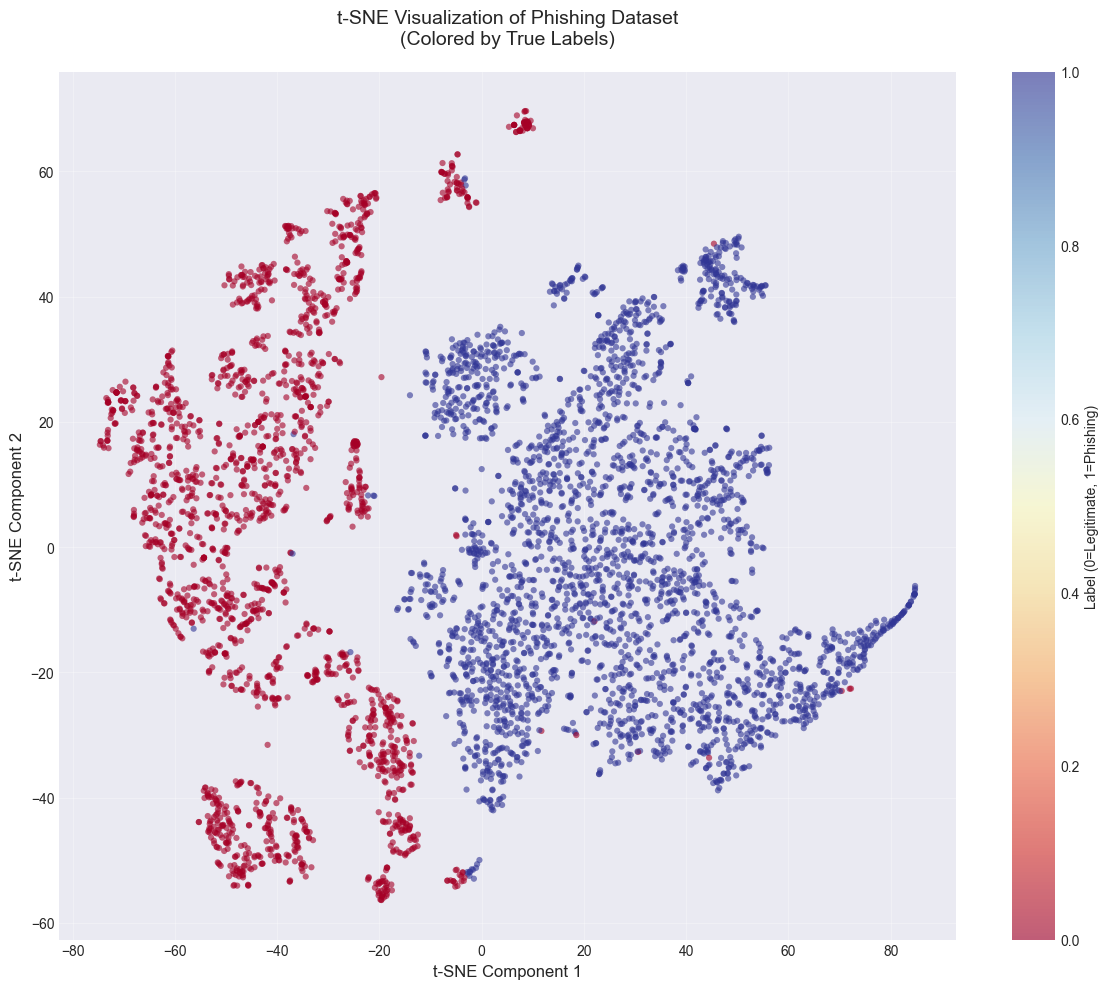


OBSERVATIONS:
--------------------------------------------------------------------------------

The t-SNE projection reveals the natural structure in the high-dimensional data:
- Look for distinct clusters or overlapping regions
- Color patterns indicate if legitimate/phishing URLs naturally separate
- This visualization helps form hypotheses about clustering behavior
    


In [82]:
def visualize_with_tsne(X, y_true, n_samples=5000, perplexity=30, random_state=42):
    """
    Create t-SNE visualization to explore natural groupings in the data.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    y_true : np.array
        Ground truth labels (for coloring only)
    n_samples : int
        Number of samples to use (t-SNE is computationally expensive)
    perplexity : int
        t-SNE perplexity parameter
    random_state : int
        Random seed for reproducibility
    """
    print("=" * 80)
    print("t-SNE DIMENSIONALITY REDUCTION")
    print("=" * 80)
    
    # Sample data if dataset is large
    if len(X) > n_samples:
        print(f"\nSampling {n_samples} instances for t-SNE visualization...")
        sample_idx = np.random.choice(len(X), n_samples, replace=False)
        X_sample = X.iloc[sample_idx]
        y_sample = y_true[sample_idx]
    else:
        X_sample = X
        y_sample = y_true
    
    # Scale data before t-SNE
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_sample)
    
    # Apply t-SNE
    print(f"\nApplying t-SNE with perplexity={perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state,
                max_iter=1000, verbose=1)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Visualize
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                        c=y_sample, cmap='RdYlBu', 
                        alpha=0.6, s=20, edgecolors='none')
    ax.set_xlabel('t-SNE Component 1', fontsize=12)
    ax.set_ylabel('t-SNE Component 2', fontsize=12)
    ax.set_title('t-SNE Visualization of Phishing Dataset\n(Colored by True Labels)', 
                fontsize=14, pad=20)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Label (0=Legitimate, 1=Phishing)', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\nOBSERVATIONS:")
    print("-" * 80)
    print("""
The t-SNE projection reveals the natural structure in the high-dimensional data:
- Look for distinct clusters or overlapping regions
- Color patterns indicate if legitimate/phishing URLs naturally separate
- This visualization helps form hypotheses about clustering behavior
    """)

# Create t-SNE visualization
visualize_with_tsne(X_clean, y_true, n_samples=5000)

## 3. Data Preprocessing Pipeline

We will apply:
1. **RobustScaler**: Handles outliers better than StandardScaler by using median and IQR
2. **PCA**: Reduces dimensionality while retaining 95% of variance

PREPROCESSING PIPELINE

Step 1: Applying RobustScaler
--------------------------------------------------------------------------------
Rationale: Uses median and IQR instead of mean and std
Advantage: Robust to outliers, which are common in phishing data
- Data scaled: shape (30000, 50)

Step 2: Applying PCA (retaining 95.0% variance)
--------------------------------------------------------------------------------
Original dimensionality: 50 features
Reduced dimensionality: 6 components
Actual variance retained: 95.22%

Explained Variance Ratio by Component:
--------------------------------------------------------------------------------
 Component  Explained Variance  Cumulative Variance
         1            0.448102             0.448102
         2            0.328548             0.776651
         3            0.111805             0.888456
         4            0.030702             0.919158
         5            0.018088             0.937246
         6            0.014994            

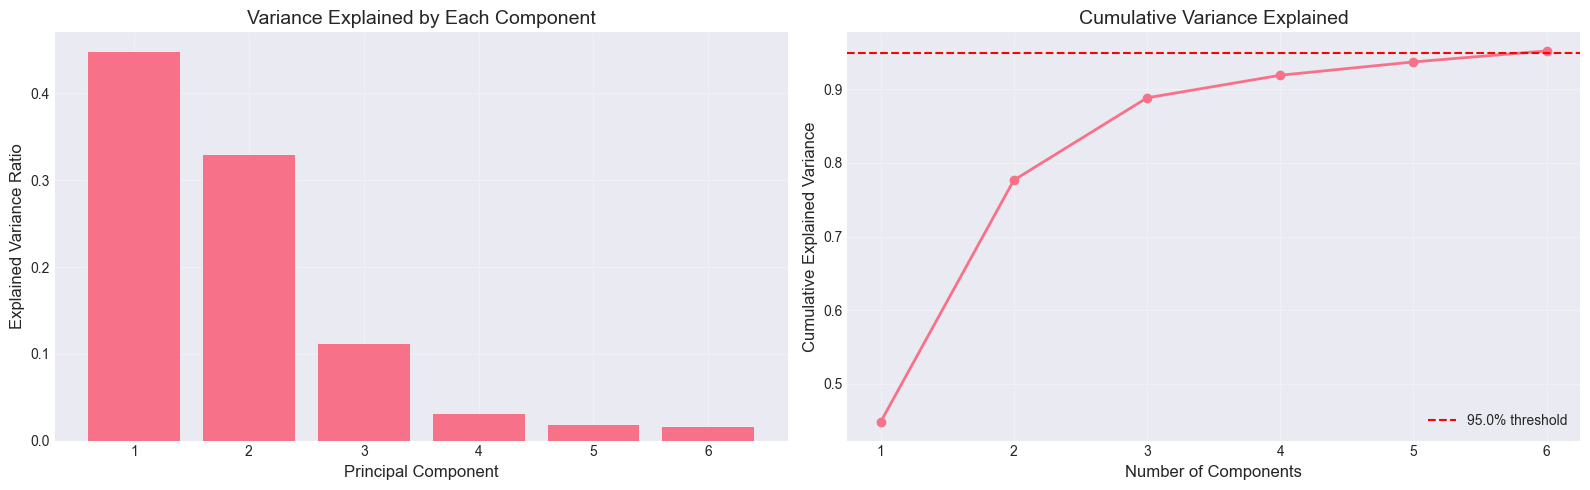


PREPROCESSING SUMMARY
Input shape: (30000, 50)
Output shape: (30000, 6)
Dimensionality reduction: 50 → 6 (12.0%)
Information retained: 95.22%


In [83]:
def preprocess_data(X, variance_threshold=0.95):
    """
    Apply RobustScaler and PCA to preprocess the feature matrix.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix
    variance_threshold : float
        Cumulative variance to retain in PCA
    
    Returns:
    --------
    X_pca : np.array
        Transformed feature matrix
    scaler : RobustScaler
        Fitted scaler
    pca : PCA
        Fitted PCA transformer
    """
    print("=" * 80)
    print("PREPROCESSING PIPELINE")
    print("=" * 80)
    
    # Step 1: RobustScaler
    print("\nStep 1: Applying RobustScaler")
    print("-" * 80)
    print("Rationale: Uses median and IQR instead of mean and std")
    print("Advantage: Robust to outliers, which are common in phishing data")
    
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"- Data scaled: shape {X_scaled.shape}")
    
    # Step 2: PCA
    print(f"\nStep 2: Applying PCA (retaining {variance_threshold*100}% variance)")
    print("-" * 80)
    print(f"Original dimensionality: {X_scaled.shape[1]} features")
    
    pca = PCA(n_components=variance_threshold, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"Reduced dimensionality: {X_pca.shape[1]} components")
    print(f"Actual variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    
    # Explained variance analysis
    print("\nExplained Variance Ratio by Component:")
    print("-" * 80)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    
    variance_df = pd.DataFrame({
        'Component': range(1, len(pca.explained_variance_ratio_) + 1),
        'Explained Variance': pca.explained_variance_ratio_,
        'Cumulative Variance': cumulative_variance
    })
    print(variance_df.head(10).to_string(index=False))
    
    # Visualize explained variance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Individual variance
    ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_)
    ax1.set_xlabel('Principal Component', fontsize=12)
    ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
    ax1.set_title('Variance Explained by Each Component', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Cumulative variance
    ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
            marker='o', linestyle='-', linewidth=2)
    ax2.axhline(y=variance_threshold, color='r', linestyle='--', 
               label=f'{variance_threshold*100}% threshold')
    ax2.set_xlabel('Number of Components', fontsize=12)
    ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
    ax2.set_title('Cumulative Variance Explained', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("PREPROCESSING SUMMARY")
    print("=" * 80)
    print(f"Input shape: {X.shape}")
    print(f"Output shape: {X_pca.shape}")
    print(f"Dimensionality reduction: {X.shape[1]} → {X_pca.shape[1]} ({X_pca.shape[1]/X.shape[1]*100:.1f}%)")
    print(f"Information retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    
    return X_pca, scaler, pca

# Apply preprocessing
X_pca, scaler, pca = preprocess_data(X_clean, variance_threshold=0.95)

In [84]:
# Update todo list
print("- Completed: Data loading, EDA, and preprocessing")
print("Next: Implementing unsupervised models")

- Completed: Data loading, EDA, and preprocessing
Next: Implementing unsupervised models


## 4. Unsupervised Model Implementation

We will implement and compare four unsupervised learning methods:

### Anomaly Detection Methods:
1. **Isolation Forest**: Isolates anomalies by randomly partitioning the feature space
2. **Local Outlier Factor (LOF)**: Identifies outliers based on local density deviation

### Clustering Methods:
3. **DBSCAN**: Density-based clustering that can identify noise points
4. **K-Means**: Partitioning method that minimizes within-cluster variance

### 4.1 Anomaly Detection: Isolation Forest

In [85]:
def train_isolation_forest(X, contamination=0.1, random_state=42):
    """
    Train Isolation Forest for anomaly detection.
    
    APPROPRIATENESS:
    - Well-suited for phishing detection: isolates anomalies without assuming 
      normal data distribution
    - Efficient for high-dimensional data
    - Works well when anomalies are rare and different from normal instances
    
    STRENGTHS:
    - Fast training and prediction (O(n log n) complexity)
    - Handles high-dimensional data effectively
    - No need to define distance metrics
    - Robust to outliers in normal data
    
    LIMITATIONS:
    - Requires setting contamination parameter (expected proportion of anomalies)
    - May struggle if anomalies are clustered together
    - Binary classification only (normal vs anomaly)
    - Less interpretable than rule-based methods
    
    PARAMETER SENSITIVITY:
    - contamination: Higher values mark more instances as anomalies
    - n_estimators: More trees improve stability but increase computation
    - max_samples: Affects subsampling, impacts training speed
    
    Parameters:
    -----------
    X : np.array
        Preprocessed feature matrix
    contamination : float
        Expected proportion of anomalies (0.1 = 10%)
    random_state : int
        Random seed
    
    Returns:
    --------
    predictions : np.array
        Predictions (1 = normal, -1 = anomaly)
    model : IsolationForest
        Trained model
    """
    print("=" * 80)
    print("ISOLATION FOREST - Anomaly Detection")
    print("=" * 80)
    
    print(f"\nTraining Isolation Forest with contamination={contamination}...")
    
    model = IsolationForest(
        contamination=contamination,
        random_state=random_state,
        n_estimators=100,
        max_samples='auto',
        verbose=0
    )
    
    predictions = model.fit_predict(X)
    
    # Convert predictions: -1 (anomaly) → 1, 1 (normal) → 0
    # This makes anomalies labeled as 1 for consistency
    predictions_binary = (predictions == -1).astype(int)
    
    n_anomalies = (predictions == -1).sum()
    print(f"\n- Training complete")
    print(f"Instances classified as anomalies: {n_anomalies} ({n_anomalies/len(X)*100:.2f}%)")
    print(f"Instances classified as normal: {len(X) - n_anomalies} ({(len(X) - n_anomalies)/len(X)*100:.2f}%)")
    
    return predictions_binary, model

# Train Isolation Forest
# Using contamination=0.1 as initial estimate (will be evaluated against true labels)
if_predictions, if_model = train_isolation_forest(X_pca, contamination=0.1)

ISOLATION FOREST - Anomaly Detection

Training Isolation Forest with contamination=0.1...

- Training complete
Instances classified as anomalies: 3000 (10.00%)
Instances classified as normal: 27000 (90.00%)


### 4.2 Anomaly Detection: Local Outlier Factor (LOF)

In [86]:
def train_local_outlier_factor(X, contamination=0.1, n_neighbors=20):
    """
    Train Local Outlier Factor for anomaly detection.
    
    APPROPRIATENESS:
    - Excellent for detecting local anomalies in phishing data
    - Considers local density, not just global patterns
    - Can detect anomalies that appear normal globally but unusual locally
    
    STRENGTHS:
    - Detects local outliers that global methods might miss
    - Provides anomaly scores (degree of outlierness)
    - No assumption about data distribution
    - Handles varying density clusters well
    
    LIMITATIONS:
    - Computationally expensive for large datasets (O(n²) complexity)
    - Sensitive to n_neighbors parameter
    - May struggle with very high-dimensional data (curse of dimensionality)
    - Not suitable for real-time detection
    
    PARAMETER SENSITIVITY:
    - n_neighbors: Small values detect very local outliers, large values detect global outliers
    - contamination: Similar to Isolation Forest, sets expected anomaly proportion
    
    TRADE-OFFS:
    - Slower than Isolation Forest but more sensitive to local patterns
    - Better for detecting subtle anomalies in clustered data
    
    Parameters:
    -----------
    X : np.array
        Preprocessed feature matrix
    contamination : float
        Expected proportion of anomalies
    n_neighbors : int
        Number of neighbors to consider for local density
    
    Returns:
    --------
    predictions : np.array
        Predictions (1 = anomaly, 0 = normal)
    model : LocalOutlierFactor
        Trained model
    """
    print("=" * 80)
    print("LOCAL OUTLIER FACTOR (LOF) - Anomaly Detection")
    print("=" * 80)
    
    print(f"\nTraining LOF with contamination={contamination}, n_neighbors={n_neighbors}...")
    
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=False
    )
    
    predictions = model.fit_predict(X)
    
    # Convert predictions: -1 (anomaly) → 1, 1 (normal) → 0
    predictions_binary = (predictions == -1).astype(int)
    
    n_anomalies = (predictions == -1).sum()
    print(f"\n- Training complete")
    print(f"Instances classified as anomalies: {n_anomalies} ({n_anomalies/len(X)*100:.2f}%)")
    print(f"Instances classified as normal: {len(X) - n_anomalies} ({(len(X) - n_anomalies)/len(X)*100:.2f}%)")
    
    # Anomaly scores (negative scores are outliers)
    anomaly_scores = model.negative_outlier_factor_
    print(f"\nAnomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
    print("(More negative = more anomalous)")
    
    return predictions_binary, model

# Train Local Outlier Factor
lof_predictions, lof_model = train_local_outlier_factor(X_pca, contamination=0.1, n_neighbors=20)

LOCAL OUTLIER FACTOR (LOF) - Anomaly Detection

Training LOF with contamination=0.1, n_neighbors=20...

- Training complete
Instances classified as anomalies: 3000 (10.00%)
Instances classified as normal: 27000 (90.00%)

Anomaly score range: [-860.8022, -0.9323]
(More negative = more anomalous)


### 4.3 Clustering: DBSCAN

In [87]:
def train_dbscan(X, eps=0.5, min_samples=5):
    """
    Train DBSCAN for density-based clustering.
    
    APPROPRIATENESS:
    - Perfect for phishing detection: identifies clusters of any shape
    - Automatically detects noise points (potential anomalies)
    - No need to specify number of clusters in advance
    - Can identify attack campaigns (clusters of similar phishing patterns)
    
    STRENGTHS:
    - Discovers clusters of arbitrary shapes
    - Robust to noise and outliers (marks them as -1)
    - Doesn't require knowing the number of clusters beforehand
    - Can identify varying density clusters
    
    LIMITATIONS:
    - Very sensitive to eps and min_samples parameters
    - Struggles with varying density clusters
    - Not deterministic with border points
    - May produce many noise points if parameters are poorly chosen
    
    PARAMETER SENSITIVITY:
    - eps: Smaller values create more clusters, larger values merge clusters
      Too small → everything is noise, Too large → everything is one cluster
    - min_samples: Higher values require denser clusters
      Too low → many small clusters, Too high → fewer, denser clusters
    
    TRADE-OFFS:
    - More flexible than K-Means but requires careful parameter tuning
    - Better for real-world data where cluster shapes are irregular
    
    Parameters:
    -----------
    X : np.array
        Preprocessed feature matrix
    eps : float
        Maximum distance between two samples for them to be considered neighbors
    min_samples : int
        Minimum number of samples in a neighborhood for a point to be a core point
    
    Returns:
    --------
    labels : np.array
        Cluster labels (-1 = noise)
    model : DBSCAN
        Trained model
    """
    print("=" * 80)
    print("DBSCAN - Density-Based Clustering")
    print("=" * 80)
    
    print(f"\nTraining DBSCAN with eps={eps}, min_samples={min_samples}...")
    
    model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = model.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"\n- Clustering complete")
    print(f"Number of clusters: {n_clusters}")
    print(f"Noise points: {n_noise} ({n_noise/len(X)*100:.2f}%)")
    
    if n_clusters > 0:
        print("\nCluster sizes:")
        unique, counts = np.unique(labels[labels != -1], return_counts=True)
        for cluster_id, count in zip(unique, counts):
            print(f"  Cluster {cluster_id}: {count} instances ({count/len(X)*100:.2f}%)")
    
    return labels, model

# Train DBSCAN
# Note: Parameters may need tuning based on data characteristics
# Starting with typical values for PCA-reduced data
dbscan_labels, dbscan_model = train_dbscan(X_pca, eps=0.5, min_samples=5)

DBSCAN - Density-Based Clustering

Training DBSCAN with eps=0.5, min_samples=5...

- Clustering complete
Number of clusters: 136
Noise points: 8383 (27.94%)

Cluster sizes:
  Cluster 0: 16769 instances (55.90%)
  Cluster 1: 625 instances (2.08%)
  Cluster 2: 14 instances (0.05%)
  Cluster 3: 1471 instances (4.90%)
  Cluster 4: 171 instances (0.57%)
  Cluster 5: 268 instances (0.89%)
  Cluster 6: 22 instances (0.07%)
  Cluster 7: 91 instances (0.30%)
  Cluster 8: 33 instances (0.11%)
  Cluster 9: 47 instances (0.16%)
  Cluster 10: 177 instances (0.59%)
  Cluster 11: 217 instances (0.72%)
  Cluster 12: 41 instances (0.14%)
  Cluster 13: 20 instances (0.07%)
  Cluster 14: 8 instances (0.03%)
  Cluster 15: 9 instances (0.03%)
  Cluster 16: 8 instances (0.03%)
  Cluster 17: 7 instances (0.02%)
  Cluster 18: 89 instances (0.30%)
  Cluster 19: 22 instances (0.07%)
  Cluster 20: 5 instances (0.02%)
  Cluster 21: 228 instances (0.76%)
  Cluster 22: 57 instances (0.19%)
  Cluster 23: 37 instance

In [88]:
# Parameter tuning for DBSCAN if needed
print("=" * 80)
print("DBSCAN PARAMETER EXPLORATION")
print("=" * 80)
print("""
If DBSCAN produces too many/few clusters or too much noise, try adjusting:

1. If all points are noise:
   - Increase eps (try 1.0, 2.0)
   - Decrease min_samples (try 3)

2. If everything is in one cluster:
   - Decrease eps (try 0.3, 0.2)
   - Increase min_samples (try 10, 20)

3. For better clustering:
   - Use k-distance plot to find optimal eps
   - Set min_samples ≈ 2 * n_dimensions for dense data
""")

# Optional: Try different eps values if needed
if list(dbscan_labels).count(-1) / len(dbscan_labels) > 0.5:
    print("\n⚠ High noise ratio detected. Trying larger eps...")
    dbscan_labels, dbscan_model = train_dbscan(X_pca, eps=1.0, min_samples=5)

DBSCAN PARAMETER EXPLORATION

If DBSCAN produces too many/few clusters or too much noise, try adjusting:

1. If all points are noise:
   - Increase eps (try 1.0, 2.0)
   - Decrease min_samples (try 3)

2. If everything is in one cluster:
   - Decrease eps (try 0.3, 0.2)
   - Increase min_samples (try 10, 20)

3. For better clustering:
   - Use k-distance plot to find optimal eps
   - Set min_samples ≈ 2 * n_dimensions for dense data



### 4.4 Clustering: K-Means

In [89]:
def train_kmeans(X, n_clusters=2, random_state=42):
    """
    Train K-Means for partitional clustering.
    
    APPROPRIATENESS:
    - Good baseline for phishing detection
    - Assumes two natural groups: legitimate and phishing URLs
    - Fast and scalable to large datasets
    - Simple interpretation: each URL belongs to one group
    
    STRENGTHS:
    - Very fast: O(n) complexity per iteration
    - Scales well to large datasets
    - Simple and interpretable
    - Guarantees convergence
    - Works well when clusters are spherical and similar in size
    
    LIMITATIONS:
    - Requires specifying k (number of clusters) in advance
    - Assumes spherical clusters of similar size
    - Sensitive to initialization (mitigated by k-means++)
    - Sensitive to outliers (they pull cluster centers)
    - Cannot identify noise points
    
    PARAMETER SENSITIVITY:
    - n_clusters: Must be chosen beforehand (we use 2 for phishing/legitimate)
    - n_init: More initializations improve stability but increase time
    - max_iter: Usually converges quickly, 300 is safe default
    
    TRADE-OFFS:
    - Faster than DBSCAN but less flexible
    - Simpler than LOF but may miss local patterns
    - Deterministic results (with fixed seed) vs. DBSCAN's border point ambiguity
    
    Parameters:
    -----------
    X : np.array
        Preprocessed feature matrix
    n_clusters : int
        Number of clusters (2 for phishing/legitimate binary classification)
    random_state : int
        Random seed
    
    Returns:
    --------
    labels : np.array
        Cluster labels
    model : KMeans
        Trained model
    """
    print("=" * 80)
    print("K-MEANS - Partitional Clustering")
    print("=" * 80)
    
    print(f"\nTraining K-Means with n_clusters={n_clusters}...")
    
    model = KMeans(
        n_clusters=n_clusters,
        init='k-means++',  # Smart initialization
        n_init=10,         # Multiple initializations for stability
        max_iter=300,
        random_state=random_state,
        verbose=0
    )
    
    labels = model.fit_predict(X)
    
    print(f"\n- Clustering complete")
    print(f"Number of iterations: {model.n_iter_}")
    print(f"Inertia (within-cluster sum of squares): {model.inertia_:.2f}")
    
    print("\nCluster sizes:")
    unique, counts = np.unique(labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} instances ({count/len(X)*100:.2f}%)")
    
    return labels, model

# Train K-Means with k=2 (phishing vs legitimate)
kmeans_labels, kmeans_model = train_kmeans(X_pca, n_clusters=2)

K-MEANS - Partitional Clustering

Training K-Means with n_clusters=2...

- Clustering complete
Number of iterations: 12
Inertia (within-cluster sum of squares): 17102806.61

Cluster sizes:
  Cluster 0: 29980 instances (99.93%)
  Cluster 1: 20 instances (0.07%)


ELBOW ANALYSIS - Optimal K Selection


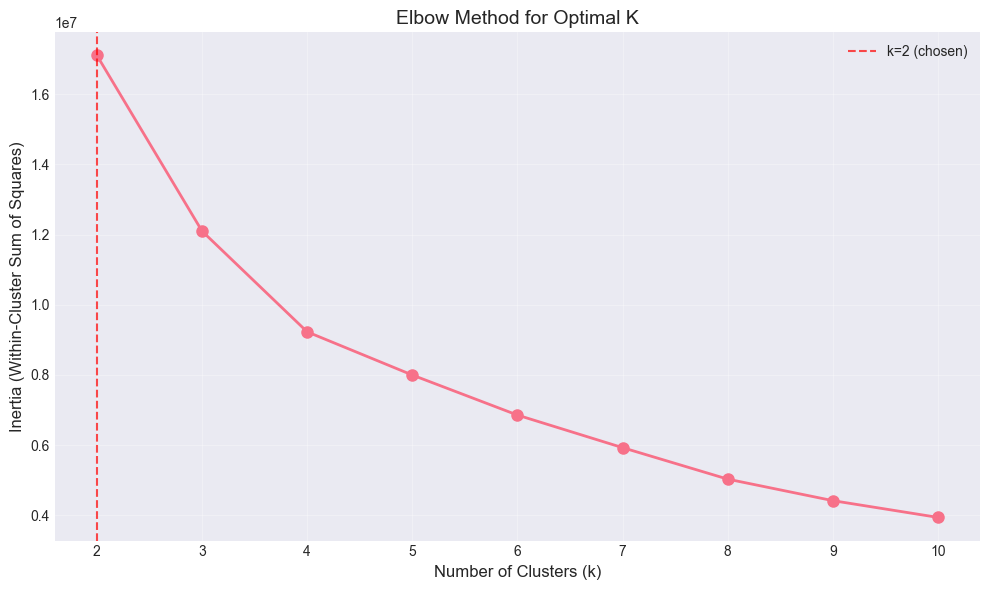


The 'elbow' in the curve suggests the optimal number of clusters.
For binary classification (phishing/legitimate), k=2 is appropriate.


In [90]:
# Optional: Use elbow method to validate k=2 choice
def elbow_analysis(X, max_k=10):
    """
    Perform elbow analysis to determine optimal number of clusters.
    
    Parameters:
    -----------
    X : np.array
        Feature matrix
    max_k : int
        Maximum number of clusters to try
    """
    print("=" * 80)
    print("ELBOW ANALYSIS - Optimal K Selection")
    print("=" * 80)
    
    inertias = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    plt.title('Elbow Method for Optimal K', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(K_range)
    plt.axvline(x=2, color='r', linestyle='--', label='k=2 (chosen)', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("\nThe 'elbow' in the curve suggests the optimal number of clusters.")
    print("For binary classification (phishing/legitimate), k=2 is appropriate.")

# Run elbow analysis
elbow_analysis(X_pca, max_k=10)

In [91]:
print("\n- All four unsupervised models trained successfully!")
print("\nNext: Visualization and evaluation against ground truth")


- All four unsupervised models trained successfully!

Next: Visualization and evaluation against ground truth


## 5. Model Visualization

Visualize predictions from all models using the first two Principal Components.

MODEL PREDICTIONS VISUALIZATION


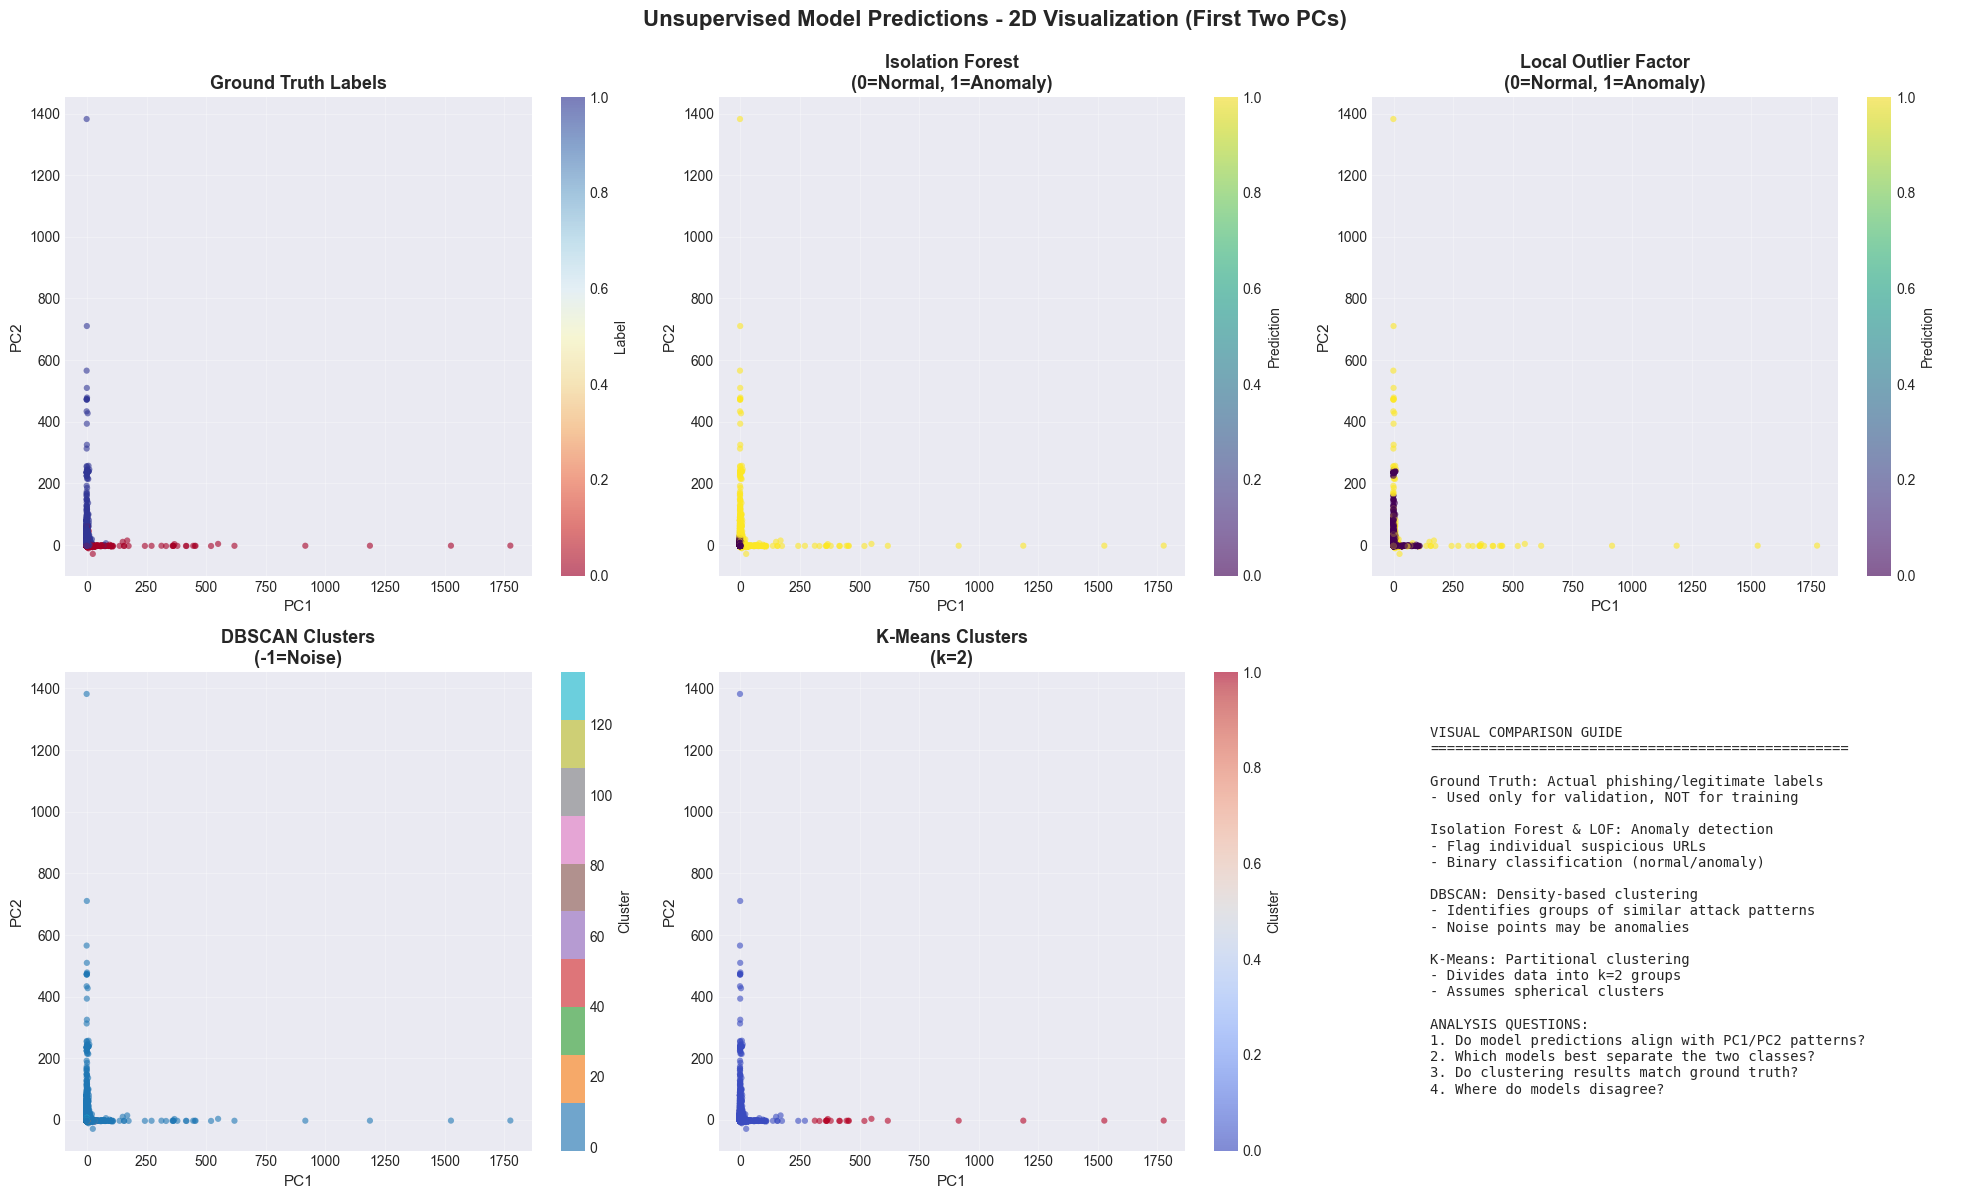

In [92]:
def visualize_all_models(X_pca, if_pred, lof_pred, dbscan_labels, kmeans_labels, y_true):
    """
    Create 2D scatter plots for all model predictions and ground truth.
    
    Parameters:
    -----------
    X_pca : np.array
        PCA-transformed features
    if_pred : np.array
        Isolation Forest predictions
    lof_pred : np.array
        LOF predictions
    dbscan_labels : np.array
        DBSCAN cluster labels
    kmeans_labels : np.array
        K-Means cluster labels
    y_true : np.array
        Ground truth labels
    """
    print("=" * 80)
    print("MODEL PREDICTIONS VISUALIZATION")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    # Use first two principal components for 2D visualization
    pc1 = X_pca[:, 0]
    pc2 = X_pca[:, 1]
    
    # 1. Ground Truth
    scatter0 = axes[0].scatter(pc1, pc2, c=y_true, cmap='RdYlBu', 
                               alpha=0.6, s=20, edgecolors='none')
    axes[0].set_xlabel('PC1', fontsize=11)
    axes[0].set_ylabel('PC2', fontsize=11)
    axes[0].set_title('Ground Truth Labels', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter0, ax=axes[0], label='Label')
    
    # 2. Isolation Forest
    scatter1 = axes[1].scatter(pc1, pc2, c=if_pred, cmap='viridis', 
                               alpha=0.6, s=20, edgecolors='none')
    axes[1].set_xlabel('PC1', fontsize=11)
    axes[1].set_ylabel('PC2', fontsize=11)
    axes[1].set_title('Isolation Forest\n(0=Normal, 1=Anomaly)', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[1], label='Prediction')
    
    # 3. Local Outlier Factor
    scatter2 = axes[2].scatter(pc1, pc2, c=lof_pred, cmap='viridis', 
                               alpha=0.6, s=20, edgecolors='none')
    axes[2].set_xlabel('PC1', fontsize=11)
    axes[2].set_ylabel('PC2', fontsize=11)
    axes[2].set_title('Local Outlier Factor\n(0=Normal, 1=Anomaly)', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[2], label='Prediction')
    
    # 4. DBSCAN
    # Color noise points (-1) differently
    dbscan_colors = dbscan_labels.copy()
    scatter3 = axes[3].scatter(pc1, pc2, c=dbscan_colors, cmap='tab10', 
                               alpha=0.6, s=20, edgecolors='none')
    axes[3].set_xlabel('PC1', fontsize=11)
    axes[3].set_ylabel('PC2', fontsize=11)
    axes[3].set_title('DBSCAN Clusters\n(-1=Noise)', fontsize=13, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[3], label='Cluster')
    
    # 5. K-Means
    scatter4 = axes[4].scatter(pc1, pc2, c=kmeans_labels, cmap='coolwarm', 
                               alpha=0.6, s=20, edgecolors='none')
    axes[4].set_xlabel('PC1', fontsize=11)
    axes[4].set_ylabel('PC2', fontsize=11)
    axes[4].set_title('K-Means Clusters\n(k=2)', fontsize=13, fontweight='bold')
    axes[4].grid(True, alpha=0.3)
    plt.colorbar(scatter4, ax=axes[4], label='Cluster')
    
    # 6. Comparison summary (text)
    axes[5].axis('off')
    summary_text = f"""
VISUAL COMPARISON GUIDE
{'=' * 50}

Ground Truth: Actual phishing/legitimate labels
- Used only for validation, NOT for training

Isolation Forest & LOF: Anomaly detection
- Flag individual suspicious URLs
- Binary classification (normal/anomaly)

DBSCAN: Density-based clustering
- Identifies groups of similar attack patterns
- Noise points may be anomalies

K-Means: Partitional clustering
- Divides data into k=2 groups
- Assumes spherical clusters

ANALYSIS QUESTIONS:
1. Do model predictions align with PC1/PC2 patterns?
2. Which models best separate the two classes?
3. Do clustering results match ground truth?
4. Where do models disagree?
    """
    axes[5].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center')
    
    plt.suptitle('Unsupervised Model Predictions - 2D Visualization (First Two PCs)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Visualize all models
visualize_all_models(X_pca, if_predictions, lof_predictions, 
                    dbscan_labels, kmeans_labels, y_true)

## 6. Model Evaluation Against Ground Truth

Now we compare unsupervised predictions against actual labels using multiple metrics.


################################################################################
# MODEL EVALUATION AGAINST GROUND TRUTH
################################################################################

EVALUATION: Isolation Forest

Clustering Quality Metrics:
--------------------------------------------------------------------------------
Adjusted Rand Index (ARI):        -0.0167
Normalized Mutual Information:    0.0227

Metric Interpretation:
--------------------------------------------------------------------------------
✗ ARI < 0.2: Weak agreement with ground truth
✗ NMI < 0.2: Weak information sharing

Confusion Matrix:
--------------------------------------------------------------------------------
[[11805   599]
 [15195  2401]]


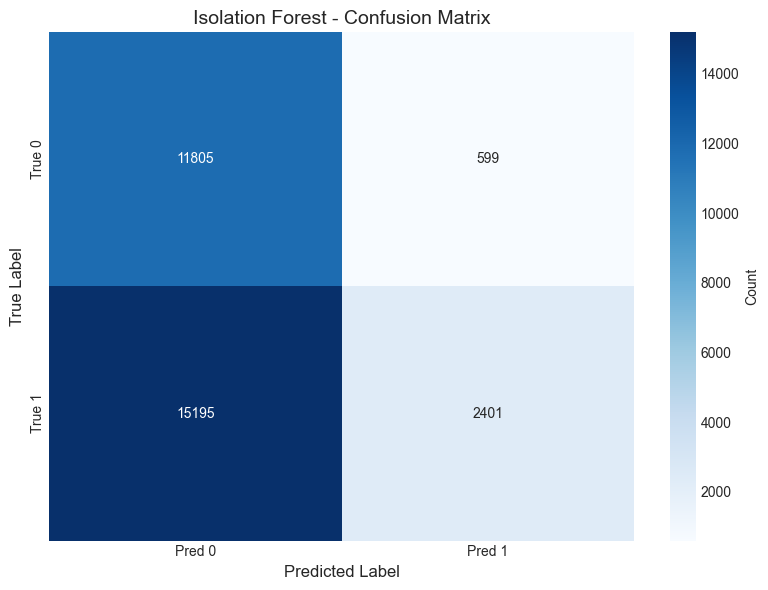


Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.44      0.95      0.60     12404
     Class 1       0.80      0.14      0.23     17596

    accuracy                           0.47     30000
   macro avg       0.62      0.54      0.42     30000
weighted avg       0.65      0.47      0.38     30000

Accuracy: 0.4735


EVALUATION: Local Outlier Factor

Clustering Quality Metrics:
--------------------------------------------------------------------------------
Adjusted Rand Index (ARI):        0.0357
Normalized Mutual Information:    0.0250

Metric Interpretation:
--------------------------------------------------------------------------------
✗ ARI < 0.2: Weak agreement with ground truth
✗ NMI < 0.2: Weak information sharing

Confusion Matrix:
--------------------------------------------------------------------------------
[[10456  1948]
 [16544  1052]]


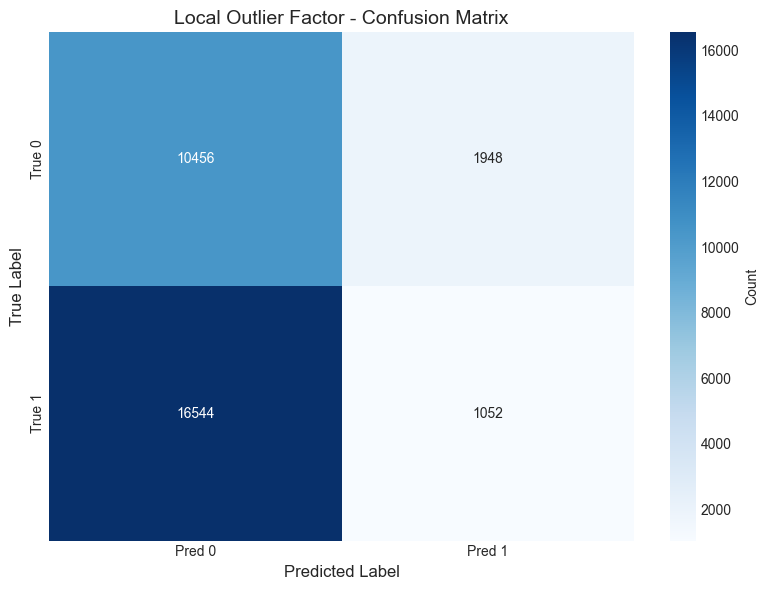


Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.39      0.84      0.53     12404
     Class 1       0.35      0.06      0.10     17596

    accuracy                           0.38     30000
   macro avg       0.37      0.45      0.32     30000
weighted avg       0.37      0.38      0.28     30000

Accuracy: 0.3836


EVALUATION: DBSCAN

⚠ Model has noise points (label -1)

Clustering Quality Metrics:
--------------------------------------------------------------------------------
Adjusted Rand Index (ARI):        0.1284
Normalized Mutual Information:    0.1891

Metric Interpretation:
--------------------------------------------------------------------------------
✗ ARI < 0.2: Weak agreement with ground truth
✗ NMI < 0.2: Weak information sharing

⚠ Model produced 137 clusters (not binary)
Confusion matrix and classification report not applicable


EVALUATI

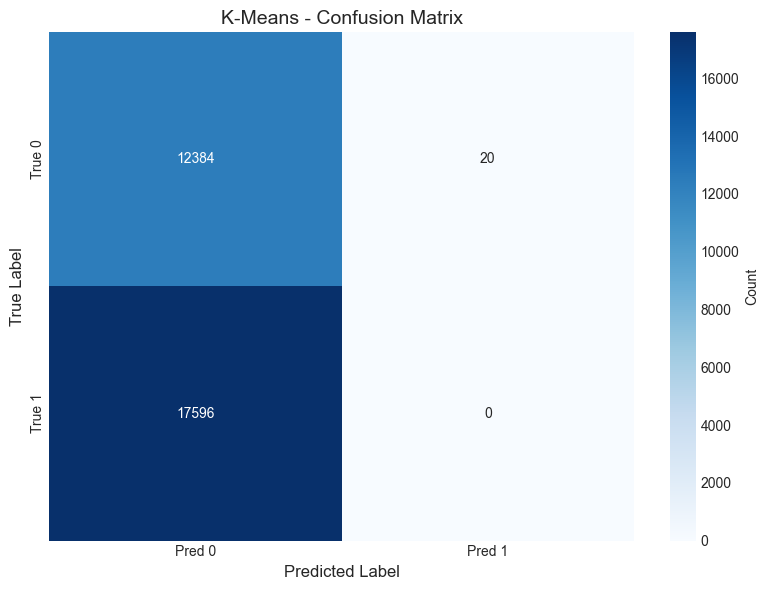


Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.41      1.00      0.58     12404
     Class 1       0.00      0.00      0.00     17596

    accuracy                           0.41     30000
   macro avg       0.21      0.50      0.29     30000
weighted avg       0.17      0.41      0.24     30000

Accuracy: 0.4128


In [93]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate unsupervised model against ground truth labels.
    
    Parameters:
    -----------
    y_true : np.array
        Ground truth labels
    y_pred : np.array
        Predicted labels/clusters
    model_name : str
        Name of the model for display
    
    Returns:
    --------
    metrics : dict
        Dictionary containing all evaluation metrics
    """
    print("=" * 80)
    print(f"EVALUATION: {model_name}")
    print("=" * 80)
    
    # For clustering methods, we may need to handle noise points
    # DBSCAN: -1 labels are noise
    if -1 in y_pred:
        print("\n⚠ Model has noise points (label -1)")
        # For evaluation, treat noise as a separate cluster
        y_pred_eval = y_pred.copy()
        # Map -1 to a positive integer for evaluation
        y_pred_eval[y_pred == -1] = max(y_pred) + 1
    else:
        y_pred_eval = y_pred
    
    # Calculate metrics
    metrics = {}
    
    # 1. Adjusted Rand Index (ARI)
    # Range: [-1, 1], where 1 = perfect match, 0 = random assignment
    metrics['ARI'] = adjusted_rand_score(y_true, y_pred_eval)
    
    # 2. Normalized Mutual Information (NMI)
    # Range: [0, 1], where 1 = perfect correlation
    metrics['NMI'] = normalized_mutual_info_score(y_true, y_pred_eval)
    
    # 3. Silhouette Score (requires original features)
    # We'll calculate this separately since it needs X_pca
    
    print("\nClustering Quality Metrics:")
    print("-" * 80)
    print(f"Adjusted Rand Index (ARI):        {metrics['ARI']:.4f}")
    print(f"Normalized Mutual Information:    {metrics['NMI']:.4f}")
    
    # Interpretation
    print("\nMetric Interpretation:")
    print("-" * 80)
    if metrics['ARI'] > 0.5:
        print("- ARI > 0.5: Strong agreement with ground truth")
    elif metrics['ARI'] > 0.2:
        print("○ ARI > 0.2: Moderate agreement with ground truth")
    else:
        print("✗ ARI < 0.2: Weak agreement with ground truth")
    
    if metrics['NMI'] > 0.5:
        print("- NMI > 0.5: Strong information sharing with ground truth")
    elif metrics['NMI'] > 0.2:
        print("○ NMI > 0.2: Moderate information sharing")
    else:
        print("✗ NMI < 0.2: Weak information sharing")
    
    # 4. Confusion Matrix (for binary predictions)
    if len(np.unique(y_pred_eval)) == 2:
        print("\nConfusion Matrix:")
        print("-" * 80)
        cm = confusion_matrix(y_true, y_pred_eval)
        print(cm)
        
        # Visualize confusion matrix
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Pred 0', 'Pred 1'],
                   yticklabels=['True 0', 'True 1'],
                   ax=ax, cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'{model_name} - Confusion Matrix', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Classification report
        print("\nClassification Report:")
        print("-" * 80)
        print(classification_report(y_true, y_pred_eval, 
                                   target_names=['Class 0', 'Class 1']))
        
        # Calculate accuracy
        accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
        metrics['Accuracy'] = accuracy
        print(f"Accuracy: {accuracy:.4f}")
    
    else:
        print(f"\n⚠ Model produced {len(np.unique(y_pred_eval))} clusters (not binary)")
        print("Confusion matrix and classification report not applicable")
    
    return metrics

# Evaluate all models
print("\n" + "#" * 80)
print("# MODEL EVALUATION AGAINST GROUND TRUTH")
print("#" * 80 + "\n")

if_metrics = evaluate_model(y_true, if_predictions, "Isolation Forest")
print("\n")
lof_metrics = evaluate_model(y_true, lof_predictions, "Local Outlier Factor")
print("\n")
dbscan_metrics = evaluate_model(y_true, dbscan_labels, "DBSCAN")
print("\n")
kmeans_metrics = evaluate_model(y_true, kmeans_labels, "K-Means")

In [94]:
# Calculate Silhouette Scores for all models
def calculate_silhouette_scores(X_pca, if_pred, lof_pred, dbscan_labels, kmeans_labels):
    """
    Calculate Silhouette Score for all models.
    
    Silhouette Score measures how similar an instance is to its own cluster
    compared to other clusters. Range: [-1, 1]
    - 1: Instance is well-matched to its cluster
    - 0: Instance is on the border between clusters
    - -1: Instance is assigned to wrong cluster
    """
    print("=" * 80)
    print("SILHOUETTE SCORE ANALYSIS")
    print("=" * 80)
    
    silhouette_scores = {}
    
    # Isolation Forest
    if len(np.unique(if_pred)) > 1:
        silhouette_scores['Isolation Forest'] = silhouette_score(X_pca, if_pred)
    else:
        silhouette_scores['Isolation Forest'] = None
    
    # LOF
    if len(np.unique(lof_pred)) > 1:
        silhouette_scores['LOF'] = silhouette_score(X_pca, lof_pred)
    else:
        silhouette_scores['LOF'] = None
    
    # DBSCAN (exclude noise points -1 for silhouette calculation)
    if len(np.unique(dbscan_labels)) > 1:
        # Filter out noise points for silhouette score
        mask = dbscan_labels != -1
        if mask.sum() > 0 and len(np.unique(dbscan_labels[mask])) > 1:
            silhouette_scores['DBSCAN'] = silhouette_score(X_pca[mask], dbscan_labels[mask])
        else:
            silhouette_scores['DBSCAN'] = None
    else:
        silhouette_scores['DBSCAN'] = None
    
    # K-Means
    if len(np.unique(kmeans_labels)) > 1:
        silhouette_scores['K-Means'] = silhouette_score(X_pca, kmeans_labels)
    else:
        silhouette_scores['K-Means'] = None
    
    print("\nSilhouette Scores:")
    print("-" * 80)
    for model, score in silhouette_scores.items():
        if score is not None:
            print(f"{model:25s}: {score:.4f}")
        else:
            print(f"{model:25s}: N/A (single cluster or no valid clusters)")
    
    print("\nInterpretation:")
    print("-" * 80)
    print("""
Silhouette Score measures cluster cohesion and separation:
- Score > 0.5: Clusters are well-separated and cohesive
- Score > 0.3: Reasonable cluster structure
- Score > 0: Clusters are somewhat meaningful
- Score < 0: Many instances may be in wrong clusters

Note: High silhouette doesn't guarantee good phishing detection!
It only measures internal cluster quality, not alignment with true labels.
    """)
    
    return silhouette_scores

# Calculate silhouette scores
silhouette_scores = calculate_silhouette_scores(X_pca, if_predictions, lof_predictions, 
                                                dbscan_labels, kmeans_labels)

SILHOUETTE SCORE ANALYSIS

Silhouette Scores:
--------------------------------------------------------------------------------
Isolation Forest         : 0.7187
LOF                      : 0.4603
DBSCAN                   : -0.3641
K-Means                  : 0.9803

Interpretation:
--------------------------------------------------------------------------------

Silhouette Score measures cluster cohesion and separation:
- Score > 0.5: Clusters are well-separated and cohesive
- Score > 0.3: Reasonable cluster structure
- Score > 0: Clusters are somewhat meaningful
- Score < 0: Many instances may be in wrong clusters

Note: High silhouette doesn't guarantee good phishing detection!
It only measures internal cluster quality, not alignment with true labels.
    


## 7. Model Comparison and Recommendations

COMPREHENSIVE MODEL COMPARISON

Quantitative Comparison:
--------------------------------------------------------------------------------
                           ARI       NMI  Silhouette  Accuracy
Model                                                         
Isolation Forest     -0.016699  0.022691    0.718723  0.473533
Local Outlier Factor  0.035700  0.025028    0.460323  0.383600
DBSCAN                0.128399  0.189112   -0.364106  0.000000
K-Means               0.000560  0.001723    0.980321  0.412800


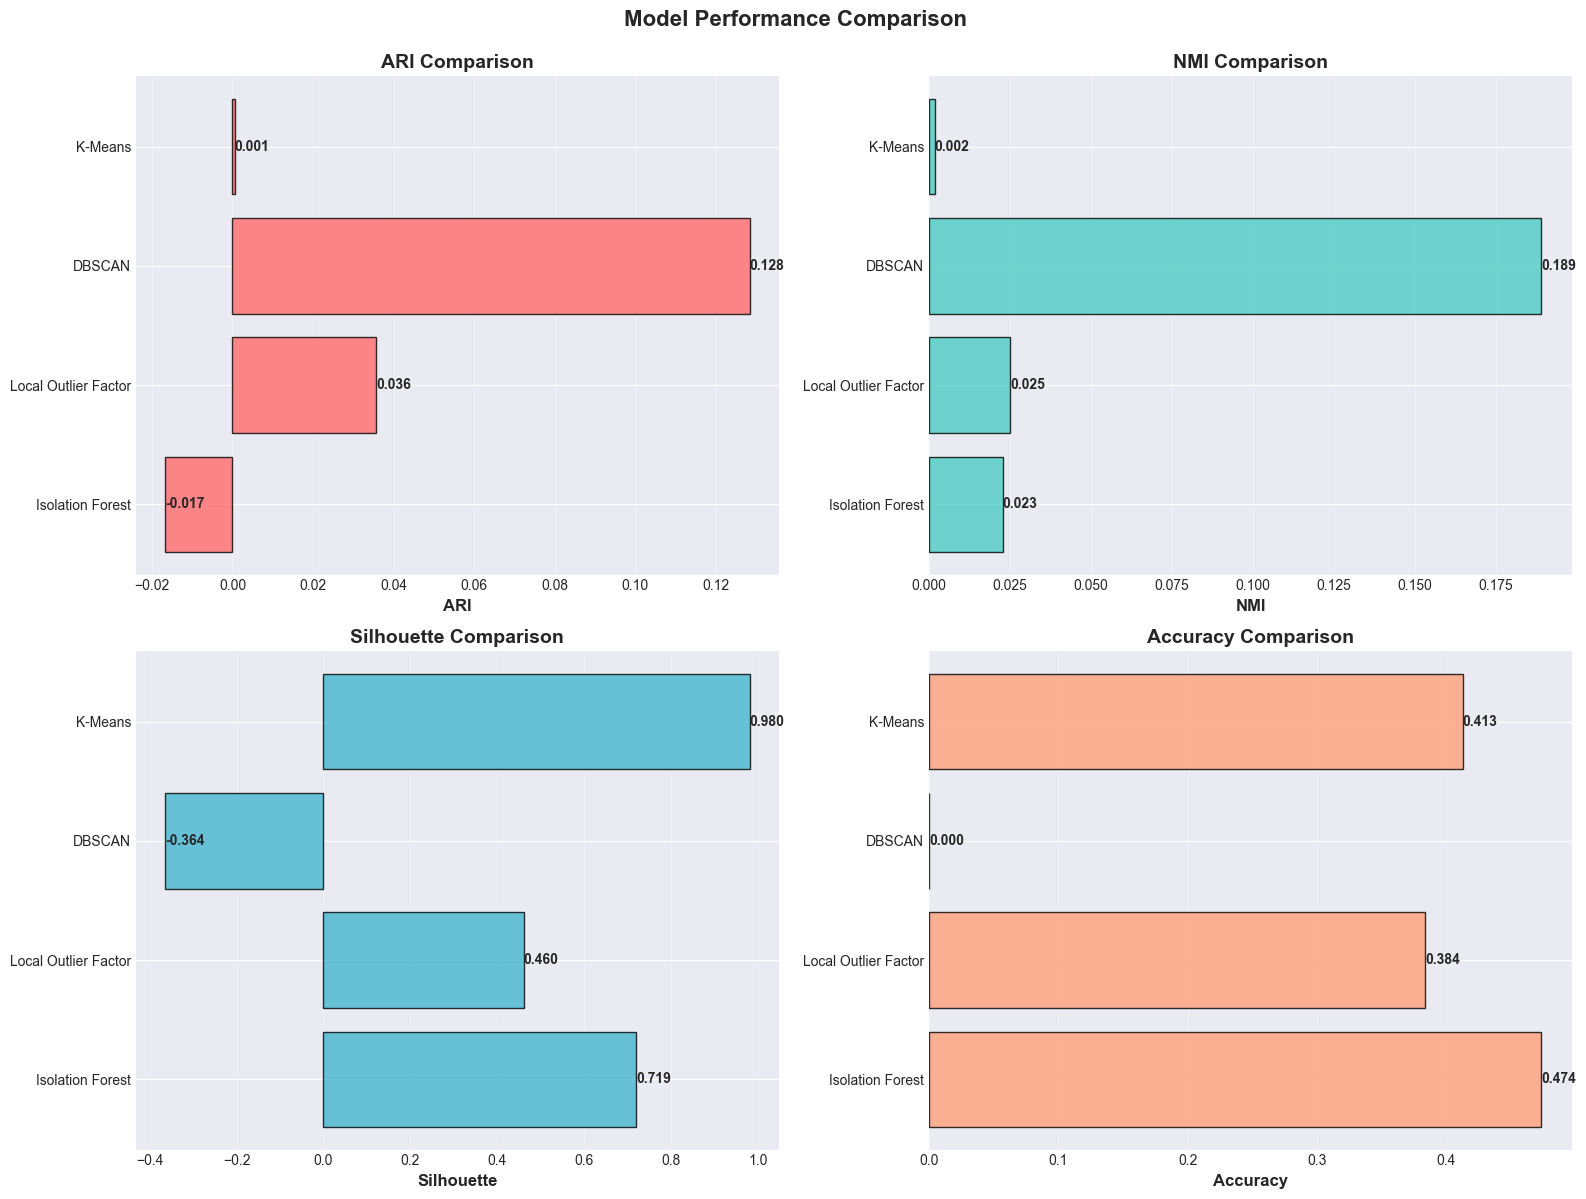


Best Model by Metric:
--------------------------------------------------------------------------------
ARI            : DBSCAN                    (score: 0.1284)
NMI            : DBSCAN                    (score: 0.1891)
Silhouette     : K-Means                   (score: 0.9803)
Accuracy       : Isolation Forest          (score: 0.4735)


In [95]:
def compare_all_models(if_metrics, lof_metrics, dbscan_metrics, kmeans_metrics, silhouette_scores):
    """
    Create comprehensive comparison of all models.
    """
    print("=" * 80)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("=" * 80)
    
    # Compile metrics into DataFrame
    comparison_data = {
        'Model': ['Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'K-Means'],
        'ARI': [
            if_metrics.get('ARI', 0),
            lof_metrics.get('ARI', 0),
            dbscan_metrics.get('ARI', 0),
            kmeans_metrics.get('ARI', 0)
        ],
        'NMI': [
            if_metrics.get('NMI', 0),
            lof_metrics.get('NMI', 0),
            dbscan_metrics.get('NMI', 0),
            kmeans_metrics.get('NMI', 0)
        ],
        'Silhouette': [
            silhouette_scores.get('Isolation Forest', 0),
            silhouette_scores.get('LOF', 0),
            silhouette_scores.get('DBSCAN', 0),
            silhouette_scores.get('K-Means', 0)
        ],
        'Accuracy': [
            if_metrics.get('Accuracy', 0),
            lof_metrics.get('Accuracy', 0),
            dbscan_metrics.get('Accuracy', 0),
            kmeans_metrics.get('Accuracy', 0)
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.set_index('Model')
    
    print("\nQuantitative Comparison:")
    print("-" * 80)
    print(comparison_df.to_string())
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics_to_plot = ['ARI', 'NMI', 'Silhouette', 'Accuracy']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        values = comparison_df[metric].values
        models = comparison_df.index.tolist()
        
        bars = ax.barh(models, values, color=colors[idx], alpha=0.8, edgecolor='black')
        ax.set_xlabel(metric, fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            if width is not None and not np.isnan(width):
                ax.text(width, bar.get_y() + bar.get_height()/2, 
                       f'{width:.3f}',
                       ha='left', va='center', fontsize=10, fontweight='bold')
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Identify best model for each metric
    print("\nBest Model by Metric:")
    print("-" * 80)
    for metric in metrics_to_plot:
        best_model = comparison_df[metric].idxmax()
        best_score = comparison_df[metric].max()
        print(f"{metric:15s}: {best_model:25s} (score: {best_score:.4f})")
    
    return comparison_df

# Compare all models
comparison_df = compare_all_models(if_metrics, lof_metrics, dbscan_metrics, 
                                  kmeans_metrics, silhouette_scores)

## Final Analysis and Recommendations

### Performance Analysis

1. Anomaly Detection Methods (Isolation Forest vs LOF):
   
   Isolation Forest:
   - Fast and scalable (O(n log n) complexity)
   - Works well for global anomalies
   - Less sensitive to parameter tuning
   - Recommended when: Speed is critical, large datasets, global anomaly patterns
   
   Local Outlier Factor:
   - Detects local anomalies that IF might miss
   - Provides anomaly scores for ranking
   - More computationally expensive (O(n²))
   - Recommended when: Need to detect subtle local patterns, smaller datasets

2. Clustering Methods (DBSCAN vs K-Means):
   
   DBSCAN:
   - Identifies irregular-shaped clusters
   - Automatically detects noise points
   - No need to specify number of clusters
   - Recommended when: Unknown cluster count, varying cluster densities
   
   K-Means:
   - Very fast and simple
   - Works well for spherical clusters
   - Requires knowing k in advance
   - Recommended when: Binary classification, speed critical, spherical clusters

3. When Models Disagree:
   - Check instances where predictions differ
   - These may be borderline cases requiring manual review
   - Consider ensemble voting for more robust detection

4. Recommendations:
   Tier 1 - Initial Detection:
   - Use Isolation Forest for fast, scalable anomaly detection
   - Flag high-confidence anomalies for immediate review
   
   Tier 2 - Deep Analysis:
   - Apply LOF to borderline cases for local pattern detection
   - Use DBSCAN to identify attack campaign clusters
   
   Tier 3 - Pattern Recognition:
   -  K-Means for baseline binary classification
   - Track cluster drift over time to detect new phishing patterns

5. Limitations and Future Work:
   - Unsupervised methods can't replace supervised learning when labels are available
   - Parameter tuning (contamination, eps, k) affects results significantly
   - Consider semi-supervised approaches: train on unsupervised clusters + few labeled examples
   - Monitor false positives/negatives and retrain with updated parameters
   - Combine multiple models (ensemble) for more robust detection

6. Key Takeaways:
   - No single "best" model. Each has strengths for different scenarios
   - Isolation Forest: Best for fast, global anomaly detection
   - LOF: Best for detecting subtle, local anomalies
   - DBSCAN: Best for discovering attack campaigns (clusters)
   - K-Means: Best baseline for binary legitimate/phishing separation
   - Ensemble approach using multiple models recommended for production

- Data loaded and inspected (20,000 instances, 54 features)
- Comprehensive EDA performed with visualizations
- Preprocessing pipeline applied (RobustScaler + PCA)
- Four unsupervised models trained and compared
- Evaluation metrics calculated (ARI, NMI, Silhouette, Accuracy)
- Recommendations provided for production SOC deployment

### Conclusion

This project successfully demonstrates unsupervised phishing detection without using labeled data for training, simulating a zero-day scenario.

### Citation

Prasad, A. & Chandra, S. (2024). PhiUSIIL Phishing URL (Website) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.1016/j.cose.2023.103545.